# Transportation Mode Detection from GPS Trajectories using Feature Engineering and Machine Learning

### Random Forest classification using engineered GPS trajectory features, followed by prediction and map visualization of unlabelled trajectories.

### 1. Load the data files, examine the dataset basic properties

#### basic exploration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd

In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/GIS2/Geolife_Trajectories_1.3/Data")

print(DATA_ROOT.exists())
print(DATA_ROOT.resolve())

True
/content/drive/MyDrive/GIS2/Geolife_Trajectories_1.3/Data


List the user folders




In [ ]:
user_folders = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

print("Number of user folders:", len(user_folders))
print("First 10 users:")
print([p.name for p in user_folders[:10]])

print("Last 10 users:")
print([p.name for p in user_folders[-10:]])

Number of user folders: 182
First 10 users:
['000', '001', '002', '003', '004', '005', '006', '007', '008', '009']
Last 10 users:
['172', '173', '174', '175', '176', '177', '178', '179', '180', '181']


Which users are the ones with labels?

In [ ]:
labelled_users = []

for user_path in user_folders:
    labels_file = user_path / "labels.txt"

    if labels_file.exists():
        labelled_users.append(user_path.name)

print("Number of users with labels:", len(labelled_users))
print(labelled_users[:20])

Number of users with labels: 69
['010', '020', '021', '052', '053', '056', '058', '059', '060', '062', '064', '065', '067', '068', '069', '073', '075', '076', '078', '080']


Counting .plt files per user: they vary a lot but should not be a problem, we have some power users with labels juhu

In [ ]:
summary_rows = []

for user_path in user_folders:
    user_id = user_path.name
    trajectory_folder = user_path / "Trajectory"
    labels_file = user_path / "labels.txt"

    if trajectory_folder.exists():
        plt_files = list(trajectory_folder.glob("*.plt"))
    else:
        plt_files = []

    summary_rows.append({
        "user_id": user_id,
        "has_labels": labels_file.exists(),
        "n_plt_files": len(plt_files)
    })

users_summary = pd.DataFrame(summary_rows)

users_summary.head()

,user_id,has_labels,n_plt_files
0,000,False,171
1,001,False,71
2,002,False,175
3,003,False,322
4,004,False,395


In [ ]:
print("Total users:", len(users_summary))
print("Users with labels:", users_summary["has_labels"].sum())
print("Total .plt files:", users_summary["n_plt_files"].sum())

users_summary.sort_values("n_plt_files", ascending=False).head(10)

Total users: 182
Users with labels: 69
Total .plt files: 18670


,user_id,has_labels,n_plt_files
128,128,True,2153
153,153,True,2024
163,163,True,809
25,025,False,757
62,062,True,706
144,144,True,610
41,041,False,557
85,085,True,427
68,068,True,408
4,004,False,395


Plot of labelled vs unlabelled users

<Axes: title={'center': 'Users with and without transportation labels'}, xlabel='has_labels'>

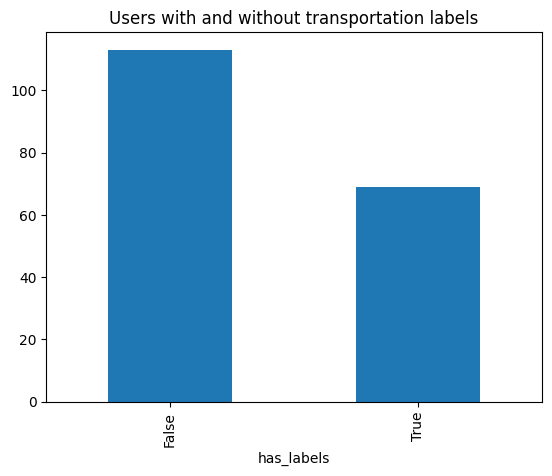

In [ ]:
users_summary["has_labels"].value_counts().plot(
    kind="bar",
    title="Users with and without transportation labels"
)

How do these label .txt files look like inside?

In [ ]:
example_user = labelled_users[0]
example_labels_path = DATA_ROOT / example_user / "labels.txt"

print("Example labelled user:", example_user)
print(example_labels_path)

with open(example_labels_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i >= 10:
            break

Example labelled user: 010
/content/drive/MyDrive/GIS2/Geolife_Trajectories_1.3/Data/010/labels.txt
'Start Time\tEnd Time\tTransportation Mode\n'
'2007/06/26 11:32:29\t2007/06/26 11:40:29\tbus\n'
'2008/03/28 14:52:54\t2008/03/28 15:59:59\ttrain\n'
'2008/03/28 16:00:00\t2008/03/28 22:02:00\ttrain\n'
'2008/03/29 01:27:50\t2008/03/29 15:59:59\ttrain\n'
'2008/03/29 16:00:00\t2008/03/30 15:59:59\ttrain\n'
'2008/03/30 16:00:00\t2008/03/31 03:13:11\ttrain\n'
'2008/03/31 04:17:59\t2008/03/31 15:31:06\ttrain\n'
'2008/03/31 16:00:08\t2008/03/31 16:09:01\ttaxi\n'
'2008/03/31 17:26:04\t2008/04/01 00:35:26\ttrain\n'
'2008/04/01 00:48:32\t2008/04/01 00:59:23\ttaxi\n'


#### loading the labels.txt files

In [ ]:
all_labels = []

for user_id in labelled_users:
    labels_path = DATA_ROOT / user_id / "labels.txt"

    labels_df = pd.read_csv(labels_path, sep="\t")
    labels_df["user_id"] = user_id

    all_labels.append(labels_df)

labels = pd.concat(all_labels, ignore_index=True)

labels.head()

,Start Time,End Time,Transportation Mode,user_id
0,2007/06/26 11:32:29,2007/06/26 11:40:29,bus,010
1,2008/03/28 14:52:54,2008/03/28 15:59:59,train,010
2,2008/03/28 16:00:00,2008/03/28 22:02:00,train,010
3,2008/03/29 01:27:50,2008/03/29 15:59:59,train,010
4,2008/03/29 16:00:00,2008/03/30 15:59:59,train,010


In [ ]:
labels["user_id"].nunique()

69

cleaning column names

In [ ]:
labels.columns = (
    labels.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

labels.head()

,start_time,end_time,transportation_mode,user_id
0,2007/06/26 11:32:29,2007/06/26 11:40:29,bus,010
1,2008/03/28 14:52:54,2008/03/28 15:59:59,train,010
2,2008/03/28 16:00:00,2008/03/28 22:02:00,train,010
3,2008/03/29 01:27:50,2008/03/29 15:59:59,train,010
4,2008/03/29 16:00:00,2008/03/30 15:59:59,train,010


In [ ]:
labels.columns

Index(['start_time', 'end_time', 'transportation_mode', 'user_id'], dtype='object')

convert label time to datetime

In [ ]:
labels["start_time"] = pd.to_datetime(
    labels["start_time"],
    format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)

labels["end_time"] = pd.to_datetime(
    labels["end_time"],
    format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)

checking transportation modes <br>

**! IMPORTANT reminder: these look very unbalanced, must be addressed**

In [ ]:
labels["transportation_mode"].value_counts()

,count
transportation_mode,
walk,6460
bus,2853
bike,2089
taxi,1179
car,993
subway,813
train,299
airplane,17
boat,7


#### loading .plt files

inspect one .plt file and remember: the first 6 rows must be cleaned

In [ ]:
example_user_path = DATA_ROOT / example_user / "Trajectory"
example_plt = sorted(example_user_path.glob("*.plt"))[0]

print(example_plt)

with open(example_plt, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i >= 12:
            break

/content/drive/MyDrive/GIS2/Geolife_Trajectories_1.3/Data/010/Trajectory/20070804033032.plt
'Geolife trajectory\n'
'WGS 84\n'
'Altitude is in Feet\n'
'Reserved 3\n'
'0,2,255,My Track,0,0,2,8421376\n'
'0\n'
'39.921712,116.472343,0,13,39298.1462037037,2007-08-04,03:30:32\n'
'39.921705,116.472343,0,13,39298.1462152778,2007-08-04,03:30:33\n'
'39.921695,116.472345,0,13,39298.1462268519,2007-08-04,03:30:34\n'
'39.921683,116.472342,0,13,39298.1462384259,2007-08-04,03:30:35\n'
'39.921672,116.472342,0,13,39298.14625,2007-08-04,03:30:36\n'
'39.921583,116.472315,0,13,39298.1462731481,2007-08-04,03:30:38\n'
'39.921572,116.472315,0,13,39298.1462847222,2007-08-04,03:30:39\n'


function to load one .plt file into a df

In [ ]:
def load_plt_file(file_path, user_id=None):
    """
    Load one Geolife .plt trajectory file.
    Skips the first 6 header lines.
    """

    col_names = [
        "lat",
        "lon",
        "unused",
        "altitude_ft",
        "date_days",
        "date",
        "time"
    ]

    df = pd.read_csv(
        file_path,
        skiprows=6,
        header=None,
        names=col_names
    )

    df["datetime"] = pd.to_datetime(
        df["date"] + " " + df["time"],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    df["user_id"] = user_id
    df["file_name"] = file_path.name

    df = df[[
        "user_id",
        "file_name",
        "datetime",
        "lat",
        "lon",
        "altitude_ft"
    ]]

    return df

test the function:

In [ ]:
test_traj = load_plt_file(example_plt, user_id=example_user)

test_traj.head(10)

,user_id,file_name,datetime,lat,lon,altitude_ft
0,010,20070804033032.plt,2007-08-04 03:30:32,39.921712,116.472343,13
1,010,20070804033032.plt,2007-08-04 03:30:33,39.921705,116.472343,13
2,010,20070804033032.plt,2007-08-04 03:30:34,39.921695,116.472345,13
3,010,20070804033032.plt,2007-08-04 03:30:35,39.921683,116.472342,13
4,010,20070804033032.plt,2007-08-04 03:30:36,39.921672,116.472342,13
5,010,20070804033032.plt,2007-08-04 03:30:38,39.921583,116.472315,13
6,010,20070804033032.plt,2007-08-04 03:30:39,39.921572,116.472315,13
7,010,20070804033032.plt,2007-08-04 03:30:40,39.921560,116.472290,13
8,010,20070804033032.plt,2007-08-04 03:30:41,39.921565,116.472290,13
9,010,20070804033032.plt,2007-08-04 03:30:42,39.921570,116.472288,13


checking shape and time range for the test user:

In [ ]:
print(test_traj.shape)
print(test_traj["datetime"].min())
print(test_traj["datetime"].max())

(1116, 6)
2007-08-04 03:30:32
2007-08-04 04:14:46


function to load all .plt files for one user:

In [ ]:
def load_user_trajectories(user_id):
    user_path = DATA_ROOT / user_id / "Trajectory"
    plt_files = sorted(user_path.glob("*.plt"))

    dfs = []

    for file_path in plt_files:
        df = load_plt_file(file_path, user_id=user_id)
        dfs.append(df)

    if len(dfs) == 0:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

test it:

In [ ]:
user_traj = load_user_trajectories(example_user)

user_traj.head()

,user_id,file_name,datetime,lat,lon,altitude_ft
0,010,20070804033032.plt,2007-08-04 03:30:32,39.921712,116.472343,13
1,010,20070804033032.plt,2007-08-04 03:30:33,39.921705,116.472343,13
2,010,20070804033032.plt,2007-08-04 03:30:34,39.921695,116.472345,13
3,010,20070804033032.plt,2007-08-04 03:30:35,39.921683,116.472342,13
4,010,20070804033032.plt,2007-08-04 03:30:36,39.921672,116.472342,13


In [ ]:
print(user_traj.shape)
print(user_traj["datetime"].min())
print(user_traj["datetime"].max())

(935576, 6)
2007-08-04 03:30:32
2009-03-21 05:34:53


Check that this user's trajectory times overlap with the labels:

In [ ]:
example_user_labels = labels[labels["user_id"] == example_user]

print("Trajectory time range:")
print(user_traj["datetime"].min(), "to", user_traj["datetime"].max())

print("\nLabel time range:")
print(example_user_labels["start_time"].min(), "to", example_user_labels["end_time"].max())

example_user_labels.head()

Trajectory time range:
2007-08-04 03:30:32 to 2009-03-21 05:34:53

Label time range:
2007-06-26 11:32:29 to 2008-12-07 12:37:28


,start_time,end_time,transportation_mode,user_id
0,2007-06-26 11:32:29,2007-06-26 11:40:29,bus,010
1,2008-03-28 14:52:54,2008-03-28 15:59:59,train,010
2,2008-03-28 16:00:00,2008-03-28 22:02:00,train,010
3,2008-03-29 01:27:50,2008-03-29 15:59:59,train,010
4,2008-03-29 16:00:00,2008-03-30 15:59:59,train,010


note: <br>
* Some GPS files exist outside the labelled period. <br>
* Some labels may also refer to times where no GPS points exist. <br>

* **only use the intersection between labels and GPS points**


#### create labelled GPS points for one user

In [ ]:
def label_user_trajectory_points(user_traj, user_labels):
    """
    Match GPS points to transportation-mode labels for one user.

    Keeps only points that fall inside a labelled time interval.
    Adds:
    - transportation_mode
    - segment_id
    """

    labelled_segments = []

    user_traj = user_traj.sort_values("datetime").copy()
    user_labels = user_labels.sort_values("start_time").copy()

    for i, row in user_labels.iterrows():
        start = row["start_time"]
        end = row["end_time"]
        mode = row["transportation_mode"]

        segment = user_traj[
            (user_traj["datetime"] >= start) &
            (user_traj["datetime"] <= end)
        ].copy()

        if len(segment) == 0:
            continue

        segment["transportation_mode"] = mode
        segment["segment_id"] = f"{row['user_id']}_{i}"
        segment["label_start_time"] = start
        segment["label_end_time"] = end

        labelled_segments.append(segment)

    if len(labelled_segments) == 0:
        return pd.DataFrame()

    return pd.concat(labelled_segments, ignore_index=True)

In [ ]:
labelled_points_one_user = label_user_trajectory_points(
    user_traj,
    example_user_labels
)

labelled_points_one_user.head()

,user_id,file_name,datetime,lat,lon,altitude_ft,transportation_mode,segment_id,label_start_time,label_end_time
0,010,20080328144824.plt,2008-03-28 14:54:40,39.894178,116.318200,-777,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
1,010,20080328144824.plt,2008-03-28 14:55:14,39.894505,116.321132,-777,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
2,010,20080328144824.plt,2008-03-28 14:56:13,39.894953,116.326452,-777,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
3,010,20080328144824.plt,2008-03-28 14:57:12,39.894600,116.332542,-777,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
4,010,20080328144824.plt,2008-03-28 14:58:11,39.889622,116.337040,-777,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59


In [ ]:
print(labelled_points_one_user.shape)

labelled_points_one_user["transportation_mode"].value_counts()

(534140, 10)


,count
transportation_mode,
train,380935
taxi,56827
walk,37106
bus,35190
subway,20385
car,2372
airplane,1325


check how much of this user's GPS data was labelled

In [ ]:
n_total_points = len(user_traj)
n_labelled_points = len(labelled_points_one_user)

print("Total GPS points:", n_total_points)
print("Labelled GPS points:", n_labelled_points)
print("Share labelled:", n_labelled_points / n_total_points)

Total GPS points: 935576
Labelled GPS points: 534140
Share labelled: 0.5709210155027491


#### load the labelled points for all users with transportation mode labels

In [ ]:
all_labelled_points = []

for user_id in labelled_users:
    print("Processing user:", user_id)

    user_traj = load_user_trajectories(user_id)
    user_labels = labels[labels["user_id"] == user_id]

    labelled_points = label_user_trajectory_points(
        user_traj,
        user_labels
    )

    if len(labelled_points) > 0:
        all_labelled_points.append(labelled_points)

labelled_points_df = pd.concat(all_labelled_points, ignore_index=True)

labelled_points_df.head()

Processing user: 010
Processing user: 020
Processing user: 021
Processing user: 052
Processing user: 053
Processing user: 056
Processing user: 058
Processing user: 059
Processing user: 060
Processing user: 062
Processing user: 064
Processing user: 065
Processing user: 067
Processing user: 068
Processing user: 069
Processing user: 073
Processing user: 075
Processing user: 076
Processing user: 078
Processing user: 080
Processing user: 081
Processing user: 082
Processing user: 084
Processing user: 085
Processing user: 086
Processing user: 087
Processing user: 088
Processing user: 089
Processing user: 091
Processing user: 092
Processing user: 096
Processing user: 097
Processing user: 098
Processing user: 100
Processing user: 101
Processing user: 102
Processing user: 104
Processing user: 105
Processing user: 106
Processing user: 107
Processing user: 108
Processing user: 110
Processing user: 111
Processing user: 112
Processing user: 114
Processing user: 115
Processing user: 116
Processing us

,user_id,file_name,datetime,lat,lon,altitude_ft,transportation_mode,segment_id,label_start_time,label_end_time
0,010,20080328144824.plt,2008-03-28 14:54:40,39.894178,116.318200,-777.0,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
1,010,20080328144824.plt,2008-03-28 14:55:14,39.894505,116.321132,-777.0,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
2,010,20080328144824.plt,2008-03-28 14:56:13,39.894953,116.326452,-777.0,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
3,010,20080328144824.plt,2008-03-28 14:57:12,39.894600,116.332542,-777.0,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59
4,010,20080328144824.plt,2008-03-28 14:58:11,39.889622,116.337040,-777.0,train,010_1,2008-03-28 14:52:54,2008-03-28 15:59:59


see the shape of this df:

In [ ]:
print(labelled_points_df.shape)

(5509013, 10)


and see the class distribution by GPS points

In [ ]:
labelled_points_df["transportation_mode"].value_counts()

,count
transportation_mode,
walk,1615614
bus,1284449
bike,959547
train,561037
car,517436
subway,312758
taxi,243097
airplane,9196
boat,3566


#### create labelled segments for all users

function matching GPS points to label:

In [ ]:
def create_labelled_segments_for_user(user_id, labels):
    """
    For one user:
    - load all GPS trajectory points
    - find label intervals
    - keep GPS points inside each labelled interval
    - return labelled GPS segments
    """

    # Load all .plt files for this user
    user_traj = load_user_trajectories(user_id)

    # Get this user's labels
    user_labels = labels[labels["user_id"] == user_id].copy()

    # Safety checks
    if len(user_traj) == 0:
        return pd.DataFrame()

    if len(user_labels) == 0:
        return pd.DataFrame()

    # Sort by time
    user_traj = user_traj.sort_values("datetime").copy()
    user_labels = user_labels.sort_values("start_time").copy()

    labelled_segments = []

    for label_idx, label_row in user_labels.iterrows():
        start = label_row["start_time"]
        end = label_row["end_time"]
        mode = label_row["transportation_mode"]

        # Select GPS points inside this labelled interval
        segment = user_traj[
            (user_traj["datetime"] >= start) &
            (user_traj["datetime"] <= end)
        ].copy()

        # Skip empty label intervals
        if len(segment) == 0:
            continue

        # Add label information
        segment["segment_id"] = f"{user_id}_{label_idx}"
        segment["transportation_mode"] = mode
        segment["label_start_time"] = start
        segment["label_end_time"] = end

        labelled_segments.append(segment)

    if len(labelled_segments) == 0:
        return pd.DataFrame()

    return pd.concat(labelled_segments, ignore_index=True)

check on one user & check result

In [ ]:
example_user = labelled_users[0]

example_segments = create_labelled_segments_for_user(
    user_id=example_user,
    labels=labels
)

example_segments.head()

,user_id,file_name,datetime,lat,lon,altitude_ft,segment_id,transportation_mode,label_start_time,label_end_time
0,010,20080328144824.plt,2008-03-28 14:54:40,39.894178,116.318200,-777,010_1,train,2008-03-28 14:52:54,2008-03-28 15:59:59
1,010,20080328144824.plt,2008-03-28 14:55:14,39.894505,116.321132,-777,010_1,train,2008-03-28 14:52:54,2008-03-28 15:59:59
2,010,20080328144824.plt,2008-03-28 14:56:13,39.894953,116.326452,-777,010_1,train,2008-03-28 14:52:54,2008-03-28 15:59:59
3,010,20080328144824.plt,2008-03-28 14:57:12,39.894600,116.332542,-777,010_1,train,2008-03-28 14:52:54,2008-03-28 15:59:59
4,010,20080328144824.plt,2008-03-28 14:58:11,39.889622,116.337040,-777,010_1,train,2008-03-28 14:52:54,2008-03-28 15:59:59


In [ ]:
print("Example user:", example_user)
print("Rows:", len(example_segments))
print("Number of segments:", example_segments["segment_id"].nunique())

example_segments["transportation_mode"].value_counts()

Example user: 010
Rows: 534140
Number of segments: 432


,count
transportation_mode,
train,380935
taxi,56827
walk,37106
bus,35190
subway,20385
car,2372
airplane,1325


In [ ]:
# inspecting segment lenth description
example_segments.groupby("segment_id").size().describe()

,0
count,432.000000
mean,1236.435185
std,3975.289240
min,1.000000
25%,179.750000
50%,381.500000
75%,660.250000
max,39419.000000


load labelled segments for all users:

In [ ]:
all_labelled_segments = []

for user_id in labelled_users:
    print("Processing user:", user_id)

    user_segments = create_labelled_segments_for_user(
        user_id=user_id,
        labels=labels
    )

    if len(user_segments) > 0:
        all_labelled_segments.append(user_segments)

labelled_points_df = pd.concat(all_labelled_segments, ignore_index=True)

Processing user: 010
Processing user: 020
Processing user: 021
Processing user: 052
Processing user: 053
Processing user: 056
Processing user: 058
Processing user: 059
Processing user: 060
Processing user: 062
Processing user: 064
Processing user: 065
Processing user: 067
Processing user: 068
Processing user: 069
Processing user: 073
Processing user: 075
Processing user: 076
Processing user: 078
Processing user: 080
Processing user: 081
Processing user: 082
Processing user: 084
Processing user: 085
Processing user: 086
Processing user: 087
Processing user: 088
Processing user: 089
Processing user: 091
Processing user: 092
Processing user: 096
Processing user: 097
Processing user: 098
Processing user: 100
Processing user: 101
Processing user: 102
Processing user: 104
Processing user: 105
Processing user: 106
Processing user: 107
Processing user: 108
Processing user: 110
Processing user: 111
Processing user: 112
Processing user: 114
Processing user: 115
Processing user: 116
Processing us

In [ ]:
print("Total labelled GPS points:", len(labelled_points_df))
print("Number of users:", labelled_points_df["user_id"].nunique())
print("Number of segments:", labelled_points_df["segment_id"].nunique())

Total labelled GPS points: 5509013
Number of users: 64
Number of segments: 9616


check class distributions & class balance by segment count

In [ ]:
labelled_points_df["transportation_mode"].value_counts()

,count
transportation_mode,
walk,1615614
bus,1284449
bike,959547
train,561037
car,517436
subway,312758
taxi,243097
airplane,9196
boat,3566


In [ ]:
segment_mode_counts = (
    labelled_points_df
    .groupby("segment_id")["transportation_mode"]
    .first()
    .value_counts()
)

segment_mode_counts

,count
transportation_mode,
walk,4041
bus,1868
bike,1571
car,787
subway,621
taxi,521
train,180
airplane,14
boat,7


<Axes: title={'center': 'Number of labelled segments per transportation mode'}, xlabel='Transportation mode', ylabel='Number of segments'>

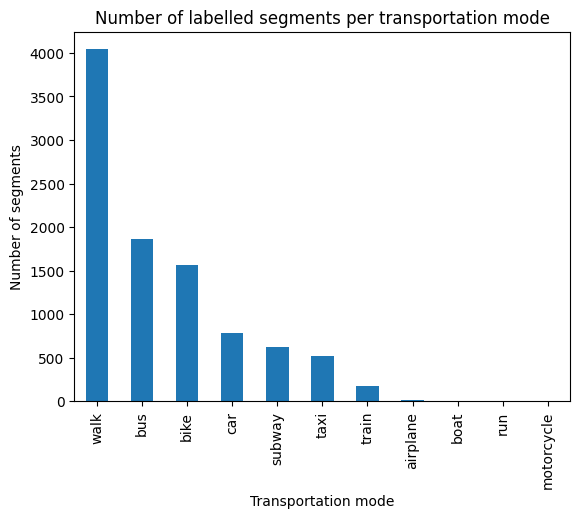

In [ ]:
segment_mode_counts.plot(
    kind="bar",
    title="Number of labelled segments per transportation mode",
    xlabel="Transportation mode",
    ylabel="Number of segments"
)

check the smallest segment sizes

In [ ]:
segment_sizes = labelled_points_df.groupby("segment_id").size()

segment_sizes.describe()

,0
count,9616.000000
mean,572.900686
std,1364.549523
min,1.000000
25%,93.000000
50%,279.000000
75%,599.000000
max,39419.000000


In [ ]:
segment_sizes.sort_values().head(20)

,0
segment_id,
084_4616,1
010_103,1
053_1108,1
128_7726,1
128_7705,1
085_5922,1
084_4587,1
153_9863,1
161_10210,1


exclude very small segments with fewer than 10 points

In [ ]:
valid_segment_ids = segment_sizes[segment_sizes >= 10].index

labelled_points_df = labelled_points_df[
    labelled_points_df["segment_id"].isin(valid_segment_ids)
].copy()

print("Remaining GPS points:", len(labelled_points_df))
print("Remaining segments:", labelled_points_df["segment_id"].nunique())

Remaining GPS points: 5507293
Remaining segments: 9280


saving the intermediate result for later

In [ ]:
labelled_points_df.to_parquet("/content/drive/MyDrive/GIS2/labelled_gps_points.parquet", index=False)

### 2. Feature engineering <br>

* from labelled GPS points -> to engineered segment-level features

#### we load the parquet file with the labelled data

In [ ]:
import numpy as np


In [ ]:
labelled_points_df = pd.read_parquet("/content/drive/MyDrive/GIS2/labelled_gps_points.parquet")

At this stage we have the raw labelled GPS points. Next step: turn each segment_id into one row with engineered features like distance, duration, average speed, max speed, stop rate, and straightness ratio.

In [ ]:
labelled_points_df.columns

Index(['user_id', 'file_name', 'datetime', 'lat', 'lon', 'altitude_ft',
       'segment_id', 'transportation_mode', 'label_start_time',
       'label_end_time'],
      dtype='object')

we need to handle the missing altitude values (-777) and convert altitude form feet to meters:

In [ ]:
labelled_points_df["altitude_ft"] = labelled_points_df["altitude_ft"].replace(-777, np.nan)

labelled_points_df["altitude_m"] = labelled_points_df["altitude_ft"] * 0.3048

In [ ]:
print("Missing altitude values:")
print(labelled_points_df["altitude_m"].isna().sum())

print("Share missing altitude:")
print(labelled_points_df["altitude_m"].isna().mean())

Missing altitude values:
55429
Share missing altitude:
0.010064654268440049


#### haversine distance function <br>

* calculate the distance between GPS coordinated in meters

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two GPS points in meters.
    """

    R = 6371000  # Earth radius in meters

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

#### feature engineerinf function for one segment

In [ ]:
def engineer_features_for_segment(segment):
    """
    Create one feature row from one labelled GPS segment.
    """

    segment = segment.sort_values("datetime").copy()

    user_id = segment["user_id"].iloc[0]
    segment_id = segment["segment_id"].iloc[0]
    mode = segment["transportation_mode"].iloc[0]
    file_name = segment["file_name"].iloc[0]

    n_points = len(segment)

    # Basic time features
    start_time = segment["datetime"].min()
    end_time = segment["datetime"].max()
    duration_s = (end_time - start_time).total_seconds()

    # If the segment is too short, return nothing
    if n_points < 2 or duration_s <= 0:
        return None

    # Shift coordinates to compare each point with the previous point
    segment["prev_lat"] = segment["lat"].shift(1)
    segment["prev_lon"] = segment["lon"].shift(1)
    segment["prev_time"] = segment["datetime"].shift(1)

    # Distance between consecutive points
    segment["step_distance_m"] = haversine_distance(
        segment["prev_lat"],
        segment["prev_lon"],
        segment["lat"],
        segment["lon"]
    )

    # Time difference between consecutive points
    segment["step_time_s"] = (
        segment["datetime"] - segment["prev_time"]
    ).dt.total_seconds()

    # Remove first row and invalid jumps
    valid_steps = segment.dropna(subset=["step_distance_m", "step_time_s"]).copy()
    valid_steps = valid_steps[valid_steps["step_time_s"] > 0]

    if len(valid_steps) == 0:
        return None

    # Speed in meters per second
    valid_steps["speed_mps"] = (
        valid_steps["step_distance_m"] / valid_steps["step_time_s"]
    )

    # Remove crazy GPS jumps
    # 80 m/s = 288 km/h, already very high for ordinary urban mobility
    valid_steps = valid_steps[valid_steps["speed_mps"] <= 80]

    if len(valid_steps) == 0:
        return None

    total_distance_m = valid_steps["step_distance_m"].sum()

    avg_speed_mps = total_distance_m / duration_s
    mean_step_speed_mps = valid_steps["speed_mps"].mean()
    median_speed_mps = valid_steps["speed_mps"].median()
    max_speed_mps = valid_steps["speed_mps"].max()
    std_speed_mps = valid_steps["speed_mps"].std()

    # Acceleration
    valid_steps["prev_speed_mps"] = valid_steps["speed_mps"].shift(1)
    valid_steps["acceleration_mps2"] = (
        valid_steps["speed_mps"] - valid_steps["prev_speed_mps"]
    ) / valid_steps["step_time_s"]

    acceleration = valid_steps["acceleration_mps2"].dropna()

    if len(acceleration) > 0:
        mean_acceleration_mps2 = acceleration.mean()
        max_acceleration_mps2 = acceleration.max()
        std_acceleration_mps2 = acceleration.std()
    else:
        mean_acceleration_mps2 = np.nan
        max_acceleration_mps2 = np.nan
        std_acceleration_mps2 = np.nan

    # Stop rate: share of steps with very low speed
    # 0.5 m/s is roughly standing / very slow movement
    stop_rate = (valid_steps["speed_mps"] < 0.5).mean()

    # Straightness ratio
    # direct distance from first to last point divided by total travelled distance
    direct_distance_m = haversine_distance(
        segment["lat"].iloc[0],
        segment["lon"].iloc[0],
        segment["lat"].iloc[-1],
        segment["lon"].iloc[-1]
    )

    if total_distance_m > 0:
        straightness_ratio = direct_distance_m / total_distance_m
    else:
        straightness_ratio = np.nan

    # Altitude features
# Altitude features in meters
    altitude_valid = segment["altitude_m"].dropna()

    if len(altitude_valid) >= 2:
        altitude_change_m = altitude_valid.iloc[-1] - altitude_valid.iloc[0]
        altitude_range_m = altitude_valid.max() - altitude_valid.min()
        altitude_mean_m = altitude_valid.mean()
        altitude_std_m = altitude_valid.std()
    else:
        altitude_change_m = np.nan
        altitude_range_m = np.nan
        altitude_mean_m = np.nan
        altitude_std_m = np.nan

    return {
        "segment_id": segment_id,
        "user_id": user_id,
        "file_name": file_name,
        "mode": mode,
        "n_points": n_points,
        "duration_s": duration_s,
        "distance_m": total_distance_m,
        "avg_speed_mps": avg_speed_mps,
        "mean_step_speed_mps": mean_step_speed_mps,
        "median_speed_mps": median_speed_mps,
        "max_speed_mps": max_speed_mps,
        "std_speed_mps": std_speed_mps,
        "mean_acceleration_mps2": mean_acceleration_mps2,
        "max_acceleration_mps2": max_acceleration_mps2,
        "std_acceleration_mps2": std_acceleration_mps2,
        "stop_rate": stop_rate,
        "straightness_ratio": straightness_ratio,
        "altitude_change_m": altitude_change_m,
        "altitude_range_m": altitude_range_m,
        "altitude_mean_m": altitude_mean_m,
        "altitude_std_m": altitude_std_m,
        "start_time": start_time,
        "end_time": end_time
    }

#### feature engineering function applied to all segments

In [ ]:
feature_rows = []

for segment_id, segment in labelled_points_df.groupby("segment_id"):
    features = engineer_features_for_segment(segment)

    if features is not None:
        feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)

features_df.head()

,segment_id,user_id,file_name,mode,n_points,duration_s,distance_m,avg_speed_mps,mean_step_speed_mps,median_speed_mps,...,max_acceleration_mps2,std_acceleration_mps2,stop_rate,straightness_ratio,altitude_change_m,altitude_range_m,altitude_mean_m,altitude_std_m,start_time,end_time
0,010_1,010,20080328144824.plt,train,69,3862.0,62604.343381,16.210343,15.477928,14.436044,...,0.103002,0.053291,0.264706,0.869391,NaN,NaN,NaN,NaN,2008-03-28 14:54:40,2008-03-28 15:59:02
1,010_100,010,20080801023537.plt,walk,128,268.0,345.081208,1.287616,2.185250,1.850453,...,2.570834,0.759478,0.039370,0.795698,0.0000,16.7640,486.991819,5.540169,2008-08-01 11:10:32,2008-08-01 11:15:00
2,010_101,010,20080801023537.plt,train,10502,13716.0,260211.697383,18.971398,20.982804,22.548642,...,8.283589,0.736543,0.004285,0.809495,-327.0504,607.1616,444.194658,121.247962,2008-08-01 11:16:58,2008-08-01 15:05:34
3,010_102,010,20080801023537.plt,train,2180,2454.0,64941.563020,26.463555,26.499813,25.295007,...,4.655619,0.662564,0.000000,0.909919,-7.9248,101.8032,132.539484,20.892295,2008-08-01 15:19:04,2008-08-01 15:59:58
4,010_104,010,20080915231738.plt,bus,395,504.0,3129.281754,6.208892,7.004240,6.813875,...,5.820962,1.158335,0.012690,0.256528,1.8288,39.9288,56.114066,9.641288,2008-09-15 23:54:20,2008-09-16 00:02:44


checking the shape

In [ ]:
print("Number of feature rows:", len(features_df))
print("Number of columns:", features_df.shape[1])

Number of feature rows: 9280
Number of columns: 23


checking the class distributions

In [ ]:
features_df["mode"].value_counts()

,count
mode,
walk,3834
bus,1831
bike,1562
car,779
subway,581
taxi,509
train,158
airplane,14
boat,7


<Axes: title={'center': 'Class distribution by labelled trajectory segment'}, xlabel='Transportation mode', ylabel='Number of segments'>

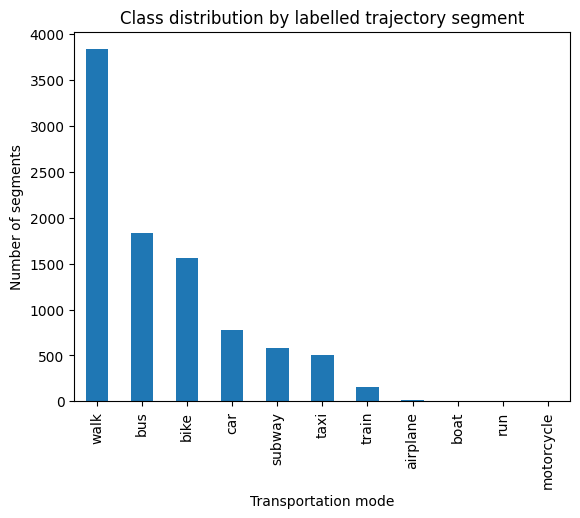

In [ ]:
features_df["mode"].value_counts().plot(
    kind="bar",
    title="Class distribution by labelled trajectory segment",
    xlabel="Transportation mode",
    ylabel="Number of segments"
)

In [ ]:
features_df[
    [
        "n_points",
        "duration_s",
        "distance_m",
        "avg_speed_mps",
        "max_speed_mps",
        "stop_rate",
        "straightness_ratio"
    ]
].describe()

,n_points,duration_s,distance_m,avg_speed_mps,max_speed_mps,stop_rate,straightness_ratio
count,9280.000000,9280.000000,9.280000e+03,9280.000000,9280.000000,9280.000000,9280.000000
mean,593.458297,2491.749246,1.092189e+04,4.095150,21.689076,0.134676,1.207200
std,1384.674462,5559.475867,5.085717e+04,4.296189,16.744808,0.138617,27.146998
min,10.000000,4.000000,1.111949e+00,0.009521,0.055815,0.000000,0.000108
25%,105.000000,464.000000,8.763065e+02,1.324309,9.016564,0.041744,0.453294
50%,295.000000,988.000000,2.691721e+03,2.752808,17.316876,0.088889,0.660624
75%,614.000000,2166.000000,8.385574e+03,5.247805,29.027969,0.186441,0.797877
max,39419.000000,86332.000000,1.588785e+06,61.035463,79.996372,1.000000,2381.034929


remove tiny or strange values

In [ ]:
features_clean = features_df.copy()

features_clean = features_clean[
    (features_clean["n_points"] >= 10) &
    (features_clean["duration_s"] >= 60) &
    (features_clean["distance_m"] >= 50)
].copy()

print("Before cleaning:", len(features_df))
print("After cleaning:", len(features_clean))

features_clean["mode"].value_counts()

Before cleaning: 9280
After cleaning: 9118


,count
mode,
walk,3685
bus,1830
bike,1554
car,779
subway,579
taxi,507
train,158
airplane,14
boat,7


handle missing values

In [ ]:
features_clean.isna().sum().sort_values(ascending=False)

,0
altitude_change_m,26
altitude_std_m,26
altitude_mean_m,26
altitude_range_m,26
segment_id,0
user_id,0
file_name,0
distance_m,0
duration_s,0
n_points,0


fill missing altitude values with 0, missing altitude information should not exclude the whole segment

In [ ]:
altitude_cols = [
    "altitude_change_m",
    "altitude_range_m",
    "altitude_mean_m",
    "altitude_std_m"
]

features_clean[altitude_cols] = features_clean[altitude_cols].fillna(0)

In [ ]:
print(features_clean.shape)

(9118, 23)


save the engineered features

In [ ]:
features_clean.to_parquet("/content/drive/MyDrive/GIS2/gps_segment_features.parquet", index=False)

### 3. Constructing models

#### load the features & imports

In [ ]:
features_clean = pd.read_parquet("/content/drive/MyDrive/GIS2/gps_segment_features.parquet")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

#### preprocessing

for model training, we need to exclude transportation modes that have too few observations in the dataset. <br>
These are: <br>
* airplane,        14 obs <br>
* boat,             7 obs <br>
* run,              3 obs <br>
* motorcycle,        2 obs <br>

Also, we need to merge: <br>
* taxi and <br>
* cars, <br>

since their movement patterns will likely not differ significantly enough to distinguish.

In [ ]:
features_model = features_clean.copy()

features_model["mode"] = features_model["mode"].replace({
    "taxi": "car_or_taxi",
    "car": "car_or_taxi"
})

rare_modes = ["airplane", "boat", "run", "motorcycle"]

features_model = features_model[
    ~features_model["mode"].isin(rare_modes)
].copy()

features_model["mode"].value_counts()

,count
mode,
walk,3685
bus,1830
bike,1554
car_or_taxi,1286
subway,579
train,158


#### prepare X and y, the predictive features and target variable

In [ ]:
features_clean.columns

Index(['segment_id', 'user_id', 'file_name', 'mode', 'n_points', 'duration_s',
       'distance_m', 'avg_speed_mps', 'mean_step_speed_mps',
       'median_speed_mps', 'max_speed_mps', 'std_speed_mps',
       'mean_acceleration_mps2', 'max_acceleration_mps2',
       'std_acceleration_mps2', 'stop_rate', 'straightness_ratio',
       'altitude_change_m', 'altitude_range_m', 'altitude_mean_m',
       'altitude_std_m', 'start_time', 'end_time'],
      dtype='object')

In [ ]:
feature_cols = [
    "n_points",
    "duration_s",
    "distance_m",
    "avg_speed_mps",
    "mean_step_speed_mps",
    "median_speed_mps",
    "max_speed_mps",
    "std_speed_mps",
    "mean_acceleration_mps2",
    "max_acceleration_mps2",
    "std_acceleration_mps2",
    "stop_rate",
    "straightness_ratio",
    "altitude_change_m",
    "altitude_range_m",
    "altitude_mean_m",
    "altitude_std_m"
]

X = features_model[feature_cols]
y = features_model["mode"]
groups = features_model["user_id"]

print(X.shape)
print(y.value_counts())

(9092, 17)
mode
walk           3685
bus            1830
bike           1554
car_or_taxi    1286
subway          579
train           158
Name: count, dtype: int64


#### train/test split by user

to get the best split, we try many and pick the best.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

all_classes = sorted(y.unique())

best_split = None
best_score = np.inf

for seed in range(500):
    sgkf = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    for train_idx_temp, test_idx_temp in sgkf.split(X, y, groups=groups):
        y_train_temp = y.iloc[train_idx_temp]
        y_test_temp = y.iloc[test_idx_temp]

        train_props = (
            y_train_temp
            .value_counts(normalize=True)
            .reindex(all_classes, fill_value=0)
        )

        test_props = (
            y_test_temp
            .value_counts(normalize=True)
            .reindex(all_classes, fill_value=0)
        )

        # smaller = more similar class distributions
        balance_score = np.abs(train_props - test_props).sum()

        # avoid splits where a class disappears from train or test
        train_counts = y_train_temp.value_counts().reindex(all_classes, fill_value=0)
        test_counts = y_test_temp.value_counts().reindex(all_classes, fill_value=0)

        if (train_counts == 0).any() or (test_counts == 0).any():
            continue

        if balance_score < best_score:
            best_score = balance_score
            best_split = (train_idx_temp, test_idx_temp, seed)

train_idx, test_idx, best_seed = best_split

print("Best seed:", best_seed)
print("Best balance score:", best_score)

Best seed: 422
Best balance score: 0.0686246178902589


In [ ]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

print("Train users:", groups_train.nunique())
print("Test users:", groups_test.nunique())

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTrain proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest proportions:")
print(y_test.value_counts(normalize=True))

Train rows: 7687
Test rows: 1405
Train users: 45
Test users: 16

Train class distribution:
mode
walk           3090
bus            1532
bike           1317
car_or_taxi    1090
subway          508
train           150
Name: count, dtype: int64

Test class distribution:
mode
walk           595
bus            298
bike           237
car_or_taxi    196
subway          71
train            8
Name: count, dtype: int64

Train proportions:
mode
walk           0.401977
bus            0.199298
bike           0.171328
car_or_taxi    0.141798
subway         0.066086
train          0.019513
Name: proportion, dtype: float64

Test proportions:
mode
walk           0.423488
bus            0.212100
bike           0.168683
car_or_taxi    0.139502
subway         0.050534
train          0.005694
Name: proportion, dtype: float64


**Note:** we have veeeery few train observations compared to other transport modes. For now, we move ahead with the **detailed model**, but we may have to merge transport modes that move on tracks vs transport modes that move on roads, to get better robustness with a **simplified model later**.

#### helper function for evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, title="Model"):
    """
    Print metrics and plot confusion matrix.
    """

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print(title)
    print("-" * len(title))
    print("Accuracy:", accuracy)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print()
    print(classification_report(y_test, y_pred))

    labels_order = sorted(y_test.unique())

    cm = confusion_matrix(y_test, y_pred, labels=labels_order)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_order
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(title + " - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return y_pred

#### baseline model to compare with

Baseline: Most Frequent Class
-----------------------------
Accuracy: 0.4234875444839858
Macro F1: 0.09916666666666667
Weighted F1: 0.2519750889679715

              precision    recall  f1-score   support

        bike       0.00      0.00      0.00       237
         bus       0.00      0.00      0.00       298
 car_or_taxi       0.00      0.00      0.00       196
      subway       0.00      0.00      0.00        71
       train       0.00      0.00      0.00         8
        walk       0.42      1.00      0.59       595

    accuracy                           0.42      1405
   macro avg       0.07      0.17      0.10      1405
weighted avg       0.18      0.42      0.25      1405



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


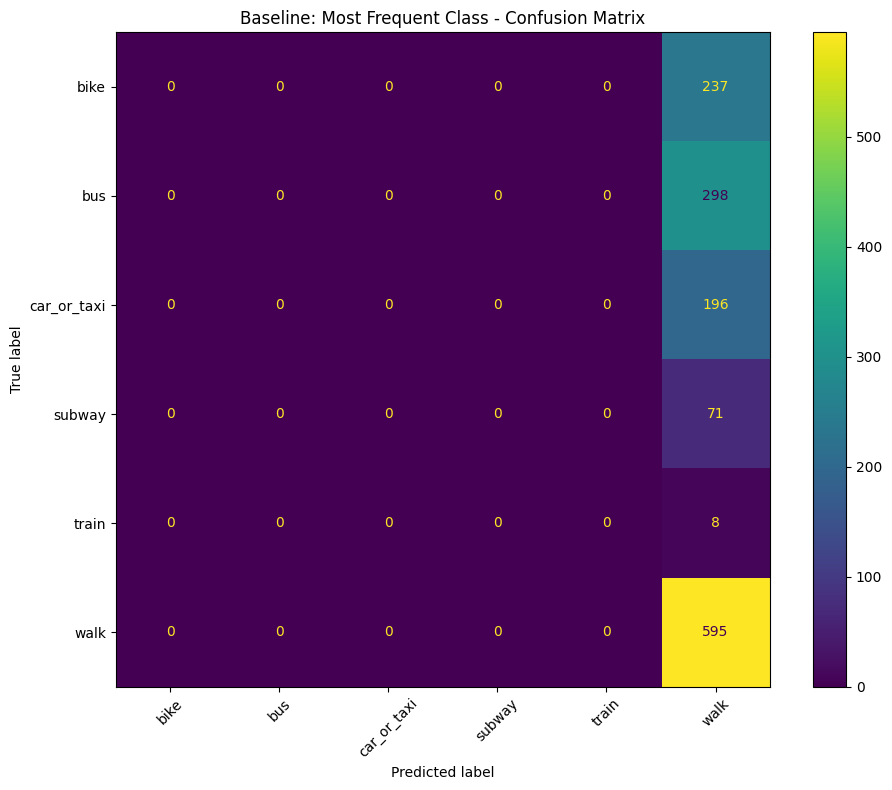

In [ ]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = evaluate_model(
    dummy_model,
    X_test,
    y_test,
    title="Baseline: Most Frequent Class"
)

#### logistic regression baseline



Logistic Regression
-------------------
Accuracy: 0.795017793594306
Macro F1: 0.6581712067804866
Weighted F1: 0.7938052907213503

              precision    recall  f1-score   support

        bike       0.78      0.81      0.79       237
         bus       0.73      0.74      0.74       298
 car_or_taxi       0.73      0.67      0.70       196
      subway       0.52      0.39      0.45        71
       train       0.26      0.62      0.37         8
        walk       0.89      0.91      0.90       595

    accuracy                           0.80      1405
   macro avg       0.65      0.69      0.66      1405
weighted avg       0.79      0.80      0.79      1405



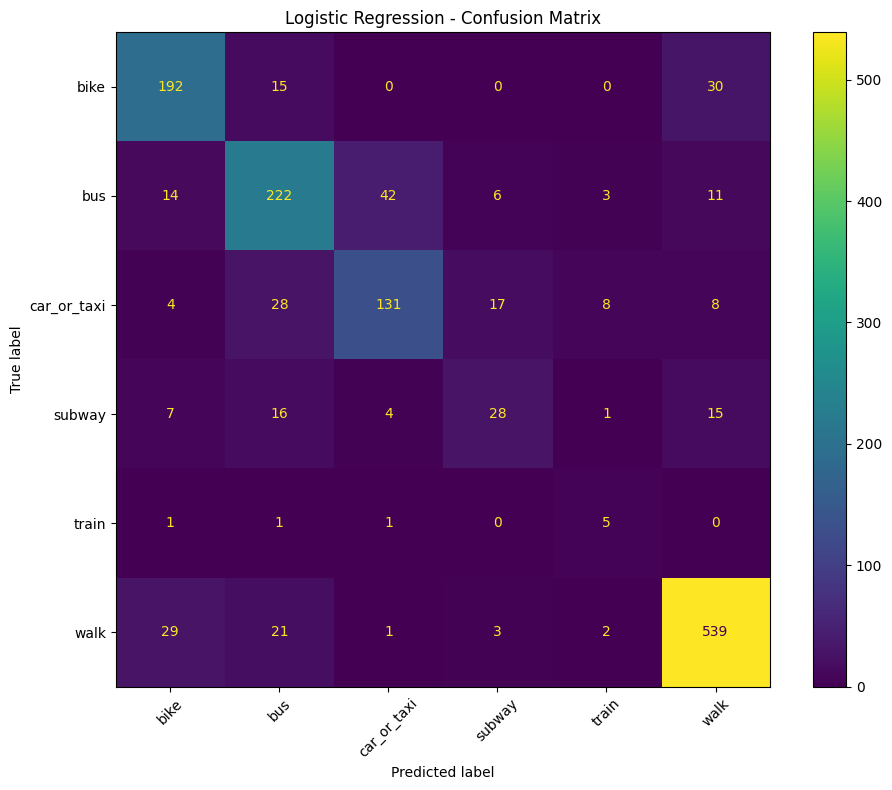

In [ ]:
log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_pred = evaluate_model(
    log_reg_model,
    X_test,
    y_test,
    title="Logistic Regression"
)

#### random forest model

Random Forest
-------------
Accuracy: 0.8612099644128114
Macro F1: 0.7638903636495481
Weighted F1: 0.8587801947531535

              precision    recall  f1-score   support

        bike       0.90      0.90      0.90       237
         bus       0.79      0.81      0.80       298
 car_or_taxi       0.79      0.75      0.77       196
      subway       0.79      0.52      0.63        71
       train       0.50      0.62      0.56         8
        walk       0.92      0.95      0.93       595

    accuracy                           0.86      1405
   macro avg       0.78      0.76      0.76      1405
weighted avg       0.86      0.86      0.86      1405



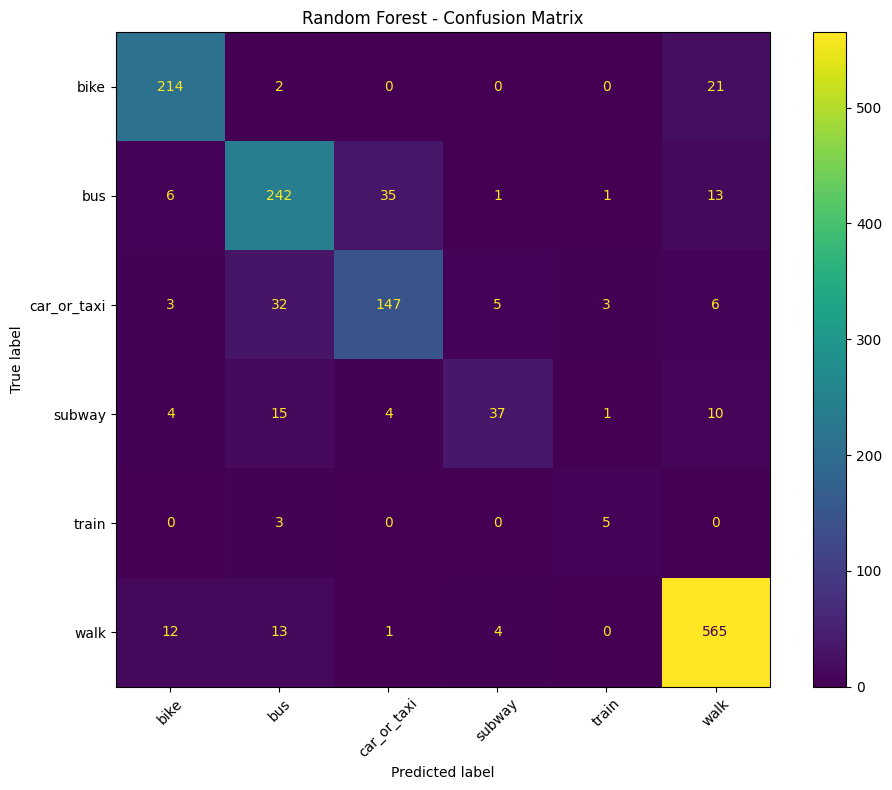

In [ ]:
rf_model_detailed = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_detailed.fit(X_train, y_train)

rf_pred = evaluate_model(
    rf_model_detailed,
    X_test,
    y_test,
    title="Random Forest"
)

# Keep the generic name too, so older cells still work before the rail-combined section.
# Important: the prediction section later uses rf_model_detailed explicitly.
rf_model = rf_model_detailed

#### feature importance for random forest

In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model_detailed.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
5,median_speed_mps,0.163566
4,mean_step_speed_mps,0.156878
7,std_speed_mps,0.135991
3,avg_speed_mps,0.119409
2,distance_m,0.074132
12,straightness_ratio,0.045990
11,stop_rate,0.042731
6,max_speed_mps,0.039617
0,n_points,0.033220
9,max_acceleration_mps2,0.031643


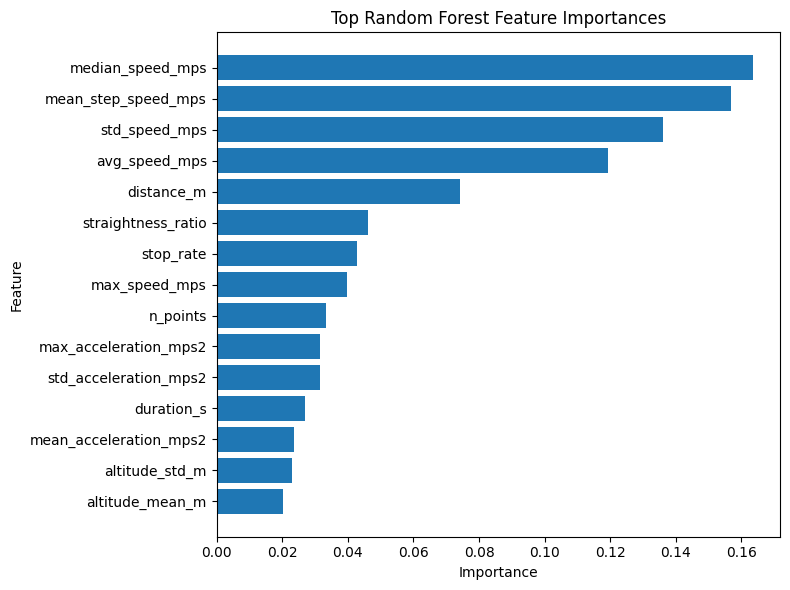

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"].head(15)[::-1],
    importance_df["importance"].head(15)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

#### gradient boosting

Gradient Boosting
-----------------
Accuracy: 0.8548042704626334
Macro F1: 0.7549717197950198
Weighted F1: 0.8523182573239486

              precision    recall  f1-score   support

        bike       0.90      0.92      0.91       237
         bus       0.77      0.80      0.78       298
 car_or_taxi       0.75      0.72      0.73       196
      subway       0.70      0.49      0.58        71
       train       0.56      0.62      0.59         8
        walk       0.93      0.95      0.94       595

    accuracy                           0.85      1405
   macro avg       0.77      0.75      0.75      1405
weighted avg       0.85      0.85      0.85      1405



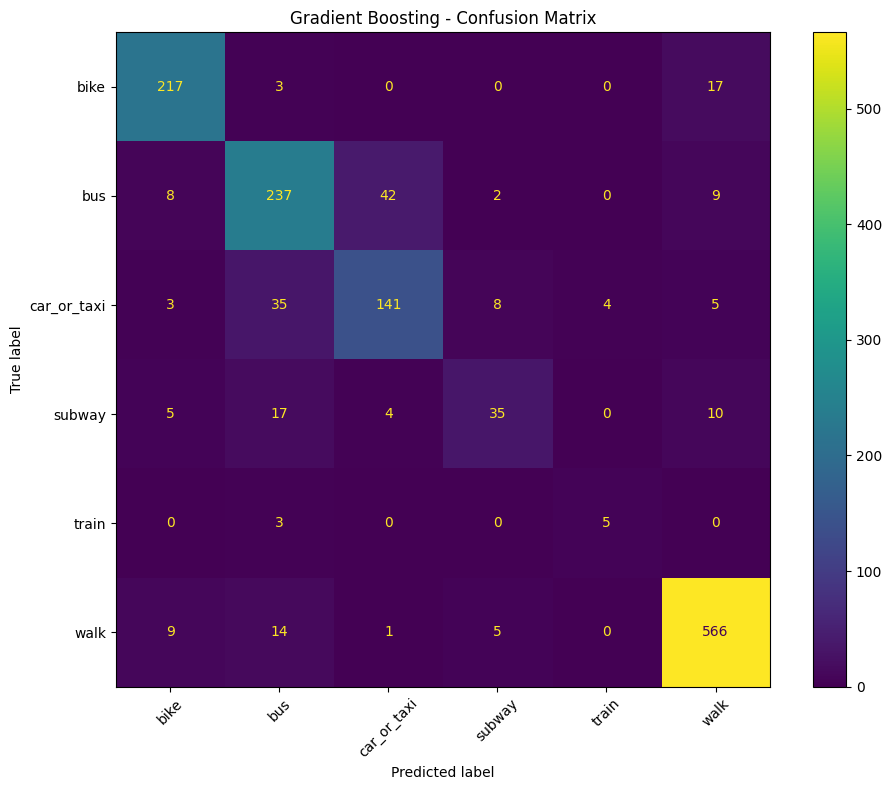

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights to deal with class imbalance
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

gb_pred = evaluate_model(
    gb_model,
    X_test,
    y_test,
    title="Gradient Boosting"
)

#### comparison of model scores

In [ ]:
results = []

for name, pred in [
    ("Baseline", dummy_pred),
    ("Logistic Regression", log_reg_pred),
    ("Random Forest", rf_pred),
    ("Gradient Boosting", gb_pred)
]:
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

results_df

,model,accuracy,macro_f1,weighted_f1
2,Random Forest,0.861210,0.763890,0.858780
3,Gradient Boosting,0.854804,0.754972,0.852318
1,Logistic Regression,0.795018,0.658171,0.793805
0,Baseline,0.423488,0.099167,0.251975


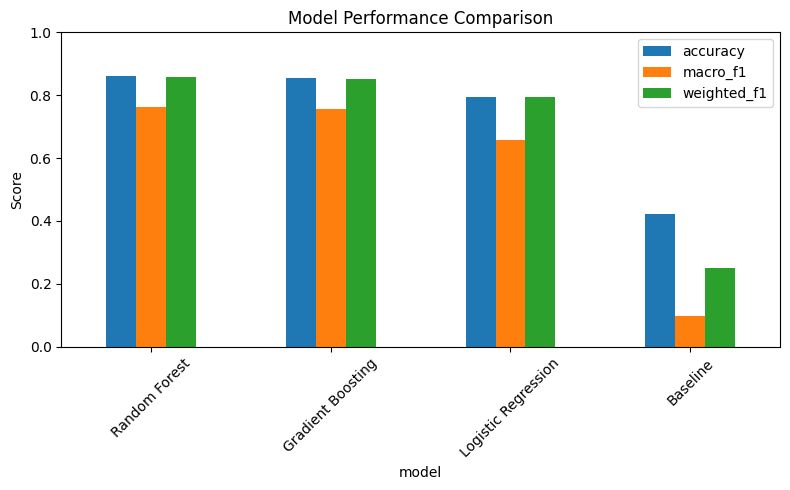

In [ ]:
results_df.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]].plot(
    kind="bar",
    figsize=(8, 5),
    title="Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt

In [ ]:
def evaluate_model_detailed(model, X_test, y_test, title="Model"):
    """
    Detailed model evaluation:
    - accuracy
    - balanced accuracy
    - classification report
    - confusion matrix
    """

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"Accuracy: {accuracy}")
    print(f"Balanced accuracy: {balanced_acc}")
    print(f"Macro F1: {macro_f1}")
    print(f"Weighted F1: {weighted_f1}")
    print()
    print("Classification report")
    print(classification_report(y_test, y_pred))

    labels_order = sorted(y_test.unique())

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels_order
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_order
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(title + " - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return y_pred

Baseline
Accuracy: 0.4234875444839858
Balanced accuracy: 0.16666666666666666
Macro F1: 0.09916666666666667
Weighted F1: 0.2519750889679715

Classification report
              precision    recall  f1-score   support

        bike       0.00      0.00      0.00       237
         bus       0.00      0.00      0.00       298
 car_or_taxi       0.00      0.00      0.00       196
      subway       0.00      0.00      0.00        71
       train       0.00      0.00      0.00         8
        walk       0.42      1.00      0.59       595

    accuracy                           0.42      1405
   macro avg       0.07      0.17      0.10      1405
weighted avg       0.18      0.42      0.25      1405



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


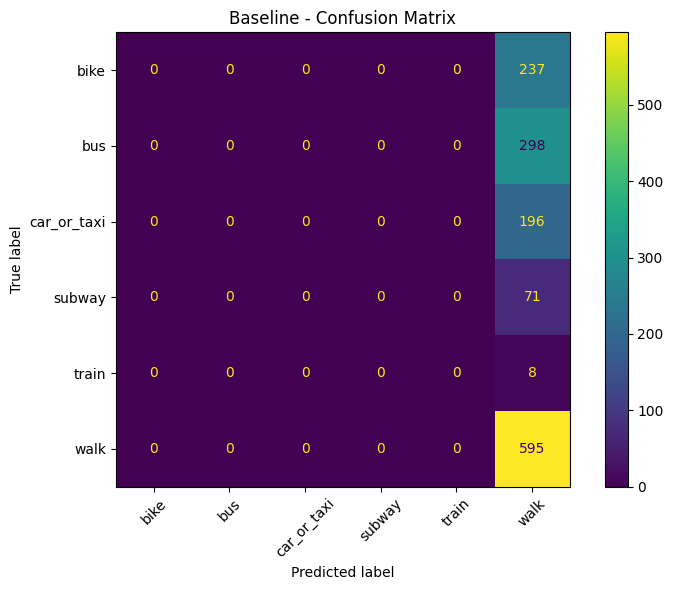

Logistic Regression
Accuracy: 0.795017793594306
Balanced accuracy: 0.691451487049092
Macro F1: 0.6581712067804866
Weighted F1: 0.7938052907213503

Classification report
              precision    recall  f1-score   support

        bike       0.78      0.81      0.79       237
         bus       0.73      0.74      0.74       298
 car_or_taxi       0.73      0.67      0.70       196
      subway       0.52      0.39      0.45        71
       train       0.26      0.62      0.37         8
        walk       0.89      0.91      0.90       595

    accuracy                           0.80      1405
   macro avg       0.65      0.69      0.66      1405
weighted avg       0.79      0.80      0.79      1405



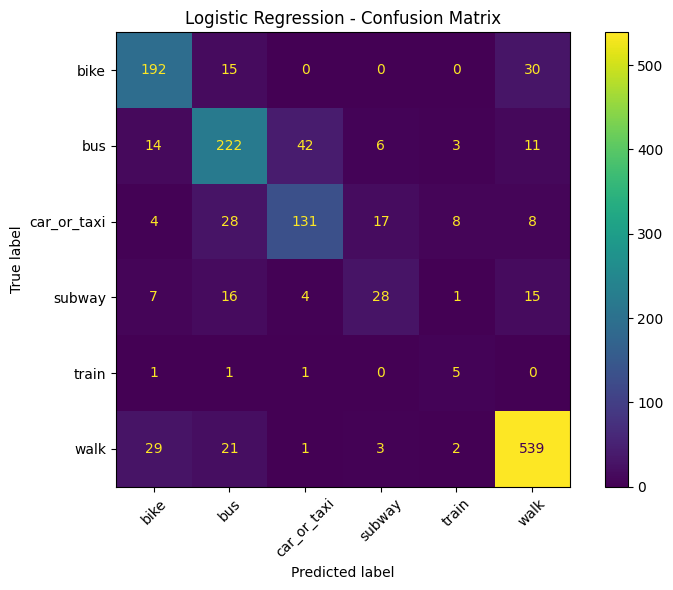

Random Forest
Accuracy: 0.8612099644128114
Balanced accuracy: 0.7601234526511326
Macro F1: 0.7638903636495481
Weighted F1: 0.8587801947531535

Classification report
              precision    recall  f1-score   support

        bike       0.90      0.90      0.90       237
         bus       0.79      0.81      0.80       298
 car_or_taxi       0.79      0.75      0.77       196
      subway       0.79      0.52      0.63        71
       train       0.50      0.62      0.56         8
        walk       0.92      0.95      0.93       595

    accuracy                           0.86      1405
   macro avg       0.78      0.76      0.76      1405
weighted avg       0.86      0.86      0.86      1405



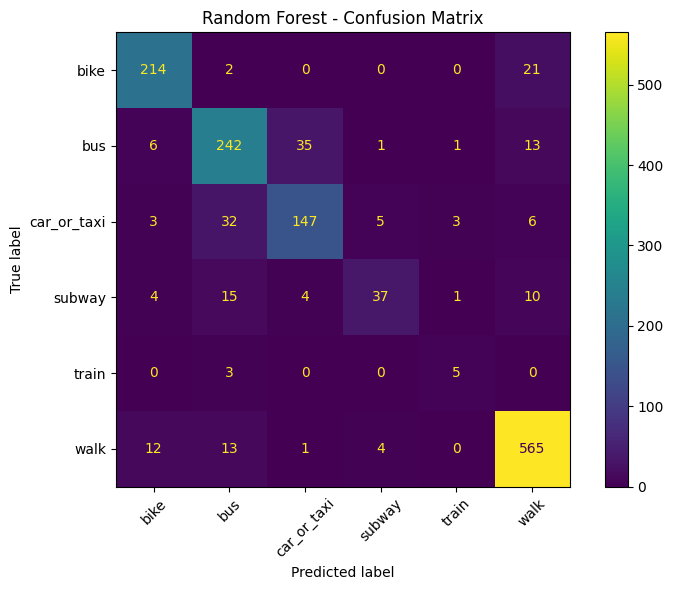

Gradient Boosting
Accuracy: 0.8548042704626334
Balanced accuracy: 0.7499199722585675
Macro F1: 0.7549717197950198
Weighted F1: 0.8523182573239486

Classification report
              precision    recall  f1-score   support

        bike       0.90      0.92      0.91       237
         bus       0.77      0.80      0.78       298
 car_or_taxi       0.75      0.72      0.73       196
      subway       0.70      0.49      0.58        71
       train       0.56      0.62      0.59         8
        walk       0.93      0.95      0.94       595

    accuracy                           0.85      1405
   macro avg       0.77      0.75      0.75      1405
weighted avg       0.85      0.85      0.85      1405



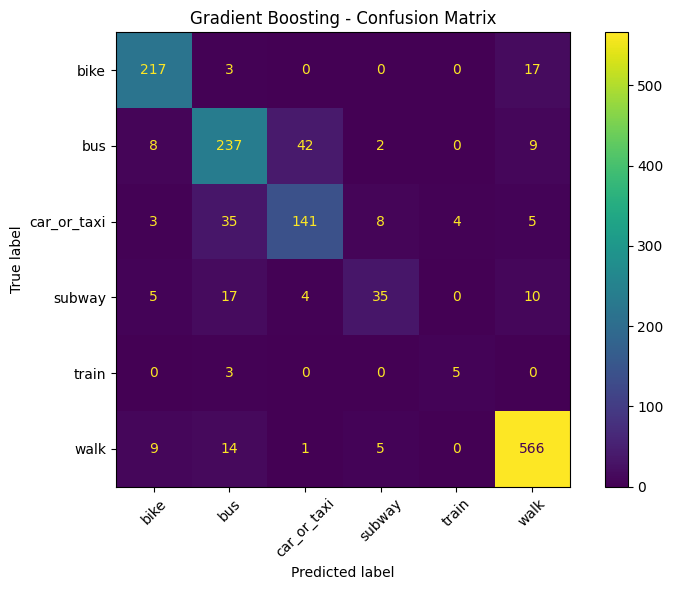

In [ ]:
dummy_pred = evaluate_model_detailed(
    dummy_model,
    X_test,
    y_test,
    title="Baseline"
)

log_reg_pred = evaluate_model_detailed(
    log_reg_model,
    X_test,
    y_test,
    title="Logistic Regression"
)

rf_pred = evaluate_model_detailed(
    rf_model_detailed,
    X_test,
    y_test,
    title="Random Forest"
)

gb_pred = evaluate_model_detailed(
    gb_model,
    X_test,
    y_test,
    title="Gradient Boosting"
)

In [ ]:
results = []

for name, pred in [
    ("Baseline", dummy_pred),
    ("Logistic Regression", log_reg_pred),
    ("Random Forest", rf_pred),
    ("Gradient Boosting", gb_pred)
]:
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

results_df

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
2,Random Forest,0.861210,0.760123,0.763890,0.858780
3,Gradient Boosting,0.854804,0.749920,0.754972,0.852318
1,Logistic Regression,0.795018,0.691451,0.658171,0.793805
0,Baseline,0.423488,0.166667,0.099167,0.251975


In [ ]:
models = [
    ("Random Forest", rf_model_detailed),
    ("Logistic Regression", log_reg_model),
    ("Gradient Boosting", gb_model)
]

for name, model in models:
    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
    print()
    print("Classification report")
    print(classification_report(y_test, y_pred))

Random Forest
Accuracy: 0.8612099644128114
Balanced accuracy: 0.7601234526511326

Classification report
              precision    recall  f1-score   support

        bike       0.90      0.90      0.90       237
         bus       0.79      0.81      0.80       298
 car_or_taxi       0.79      0.75      0.77       196
      subway       0.79      0.52      0.63        71
       train       0.50      0.62      0.56         8
        walk       0.92      0.95      0.93       595

    accuracy                           0.86      1405
   macro avg       0.78      0.76      0.76      1405
weighted avg       0.86      0.86      0.86      1405

Logistic Regression
Accuracy: 0.795017793594306
Balanced accuracy: 0.691451487049092

Classification report
              precision    recall  f1-score   support

        bike       0.78      0.81      0.79       237
         bus       0.73      0.74      0.74       298
 car_or_taxi       0.73      0.67      0.70       196
      subway       0.52     

### 4. the simpler models to increase robustness: (spoiler does not increase robustness)<br> Create the rail-combined models

#### merge train and subway into the rail_transport category

In [ ]:
features_model_rail = features_clean.copy()

# Merge similar / rare classes
features_model_rail["mode"] = features_model_rail["mode"].replace({
    "taxi": "car_or_taxi",
    "car": "car_or_taxi",
    "train": "rail_transport",
    "subway": "rail_transport"
})

# Remove very rare classes
rare_modes = ["airplane", "boat", "run", "motorcycle"]

features_model_rail = features_model_rail[
    ~features_model_rail["mode"].isin(rare_modes)
].copy()

features_model_rail["mode"].value_counts()

,count
mode,
walk,3685
bus,1830
bike,1554
car_or_taxi,1286
rail_transport,737


#### X, y, and groups

In [ ]:
X = features_model_rail[feature_cols]
y = features_model_rail["mode"]
groups = features_model_rail["user_id"]

print("X shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

print("\nClass proportions:")
print(y.value_counts(normalize=True))

X shape: (9092, 17)

Class distribution:
mode
walk              3685
bus               1830
bike              1554
car_or_taxi       1286
rail_transport     737
Name: count, dtype: int64

Class proportions:
mode
walk              0.405301
bus               0.201276
bike              0.170919
car_or_taxi       0.141443
rail_transport    0.081060
Name: proportion, dtype: float64


#### balanced, user-based split

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

all_classes = sorted(y.unique())

best_split = None
best_score = np.inf

for seed in range(500):
    sgkf = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    for train_idx_temp, test_idx_temp in sgkf.split(X, y, groups=groups):
        y_train_temp = y.iloc[train_idx_temp]
        y_test_temp = y.iloc[test_idx_temp]

        train_props = (
            y_train_temp
            .value_counts(normalize=True)
            .reindex(all_classes, fill_value=0)
        )

        test_props = (
            y_test_temp
            .value_counts(normalize=True)
            .reindex(all_classes, fill_value=0)
        )

        balance_score = np.abs(train_props - test_props).sum()

        train_counts = y_train_temp.value_counts().reindex(all_classes, fill_value=0)
        test_counts = y_test_temp.value_counts().reindex(all_classes, fill_value=0)

        # Avoid missing classes in either split
        if (train_counts == 0).any() or (test_counts == 0).any():
            continue

        if balance_score < best_score:
            best_score = balance_score
            best_split = (train_idx_temp, test_idx_temp, seed)

train_idx, test_idx, best_seed = best_split

print("Best seed:", best_seed)
print("Best balance score:", best_score)

Best seed: 404
Best balance score: 0.052966808796425


In [ ]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

print("Train users:", groups_train.nunique())
print("Test users:", groups_test.nunique())

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTrain proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest proportions:")
print(y_test.value_counts(normalize=True))

Train rows: 8699
Test rows: 393
Train users: 50
Test users: 11

Train class distribution:
mode
walk              3525
bus               1758
bike              1485
car_or_taxi       1223
rail_transport     708
Name: count, dtype: int64

Test class distribution:
mode
walk              160
bus                72
bike               69
car_or_taxi        63
rail_transport     29
Name: count, dtype: int64

Train proportions:
mode
walk              0.405219
bus               0.202092
bike              0.170709
car_or_taxi       0.140591
rail_transport    0.081389
Name: proportion, dtype: float64

Test proportions:
mode
walk              0.407125
bus               0.183206
bike              0.175573
car_or_taxi       0.160305
rail_transport    0.073791
Name: proportion, dtype: float64


#### re-train models

Baseline
Accuracy: 0.4071246819338422
Balanced accuracy: 0.2
Macro F1: 0.11573236889692587
Weighted F1: 0.2355875193830552

Classification report
                precision    recall  f1-score   support

          bike       0.00      0.00      0.00        69
           bus       0.00      0.00      0.00        72
   car_or_taxi       0.00      0.00      0.00        63
rail_transport       0.00      0.00      0.00        29
          walk       0.41      1.00      0.58       160

      accuracy                           0.41       393
     macro avg       0.08      0.20      0.12       393
  weighted avg       0.17      0.41      0.24       393



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


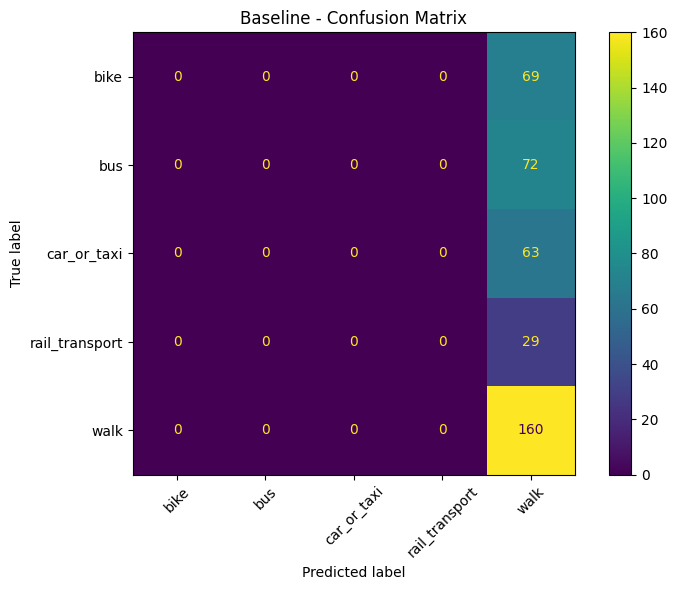

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

dummy_pred = evaluate_model_detailed(
    dummy_model,
    X_test,
    y_test,
    title="Baseline"
)

Logistic Regression
Accuracy: 0.7201017811704835
Balanced accuracy: 0.6552555864924681
Macro F1: 0.6501644704861378
Weighted F1: 0.7215936049708179

Classification report
                precision    recall  f1-score   support

          bike       0.63      0.71      0.67        69
           bus       0.67      0.57      0.62        72
   car_or_taxi       0.68      0.70      0.69        63
rail_transport       0.39      0.45      0.42        29
          walk       0.87      0.85      0.86       160

      accuracy                           0.72       393
     macro avg       0.65      0.66      0.65       393
  weighted avg       0.73      0.72      0.72       393



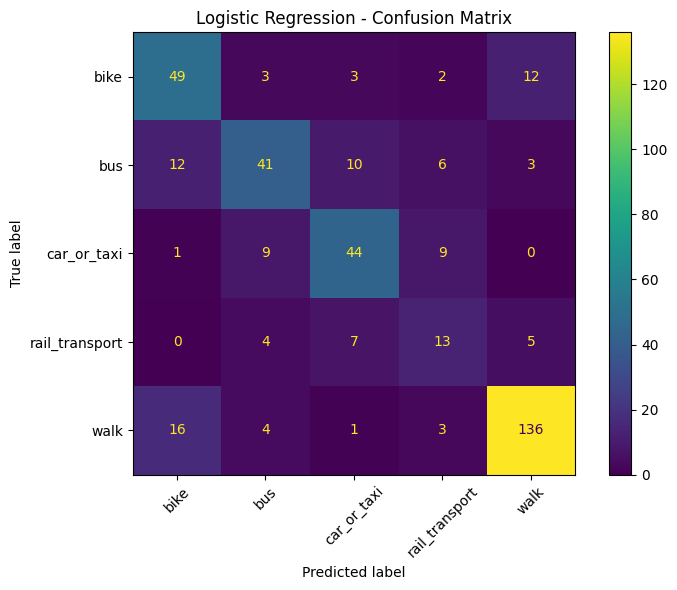

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_pred = evaluate_model_detailed(
    log_reg_model,
    X_test,
    y_test,
    title="Logistic Regression"
)

#### evaluation

Random Forest - Rail Combined
Accuracy: 0.8040712468193384
Balanced accuracy: 0.7666650603269793
Macro F1: 0.7631509184201279
Weighted F1: 0.8036188080857357

Classification report
                precision    recall  f1-score   support

          bike       0.74      0.77      0.75        69
           bus       0.73      0.67      0.70        72
   car_or_taxi       0.81      0.76      0.79        63
rail_transport       0.64      0.72      0.68        29
          walk       0.90      0.91      0.90       160

      accuracy                           0.80       393
     macro avg       0.76      0.77      0.76       393
  weighted avg       0.80      0.80      0.80       393



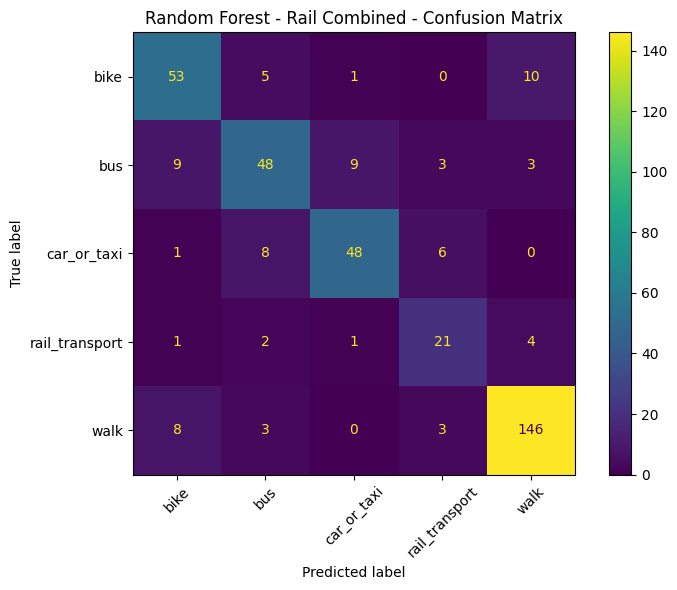

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model_rail = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_rail.fit(X_train, y_train)

rf_rail_pred = evaluate_model_detailed(
    rf_model_rail,
    X_test,
    y_test,
    title="Random Forest - Rail Combined"
)

# Do NOT overwrite rf_model_detailed here.
# The rail-combined model is kept separately because it performed worse.

Gradient Boosting
Accuracy: 0.811704834605598
Balanced accuracy: 0.7889752445205968
Macro F1: 0.7807885005906051
Weighted F1: 0.8117722986493604

Classification report
                precision    recall  f1-score   support

          bike       0.69      0.81      0.75        69
           bus       0.80      0.65      0.72        72
   car_or_taxi       0.83      0.79      0.81        63
rail_transport       0.68      0.79      0.73        29
          walk       0.90      0.89      0.90       160

      accuracy                           0.81       393
     macro avg       0.78      0.79      0.78       393
  weighted avg       0.82      0.81      0.81       393



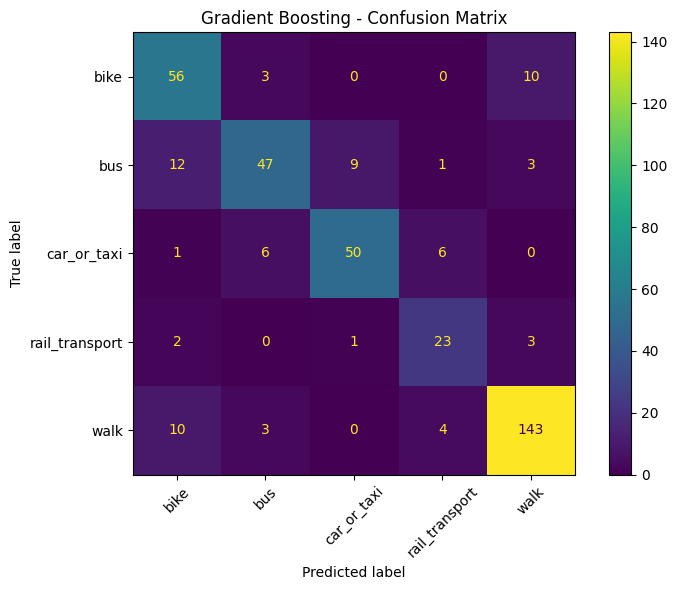

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

gb_pred = evaluate_model_detailed(
    gb_model,
    X_test,
    y_test,
    title="Gradient Boosting"
)

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

results = []

for name, pred in [
    ("Baseline", dummy_pred),
    ("Logistic Regression", log_reg_pred),
    ("Random Forest - Rail Combined", rf_rail_pred),
    ("Gradient Boosting", gb_pred)
]:
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted")
    })

results_rail_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

results_rail_df

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
3,Gradient Boosting,0.811705,0.788975,0.780789,0.811772
2,Random Forest - Rail Combined,0.804071,0.766665,0.763151,0.803619
1,Logistic Regression,0.720102,0.655256,0.650164,0.721594
0,Baseline,0.407125,0.200000,0.115732,0.235588


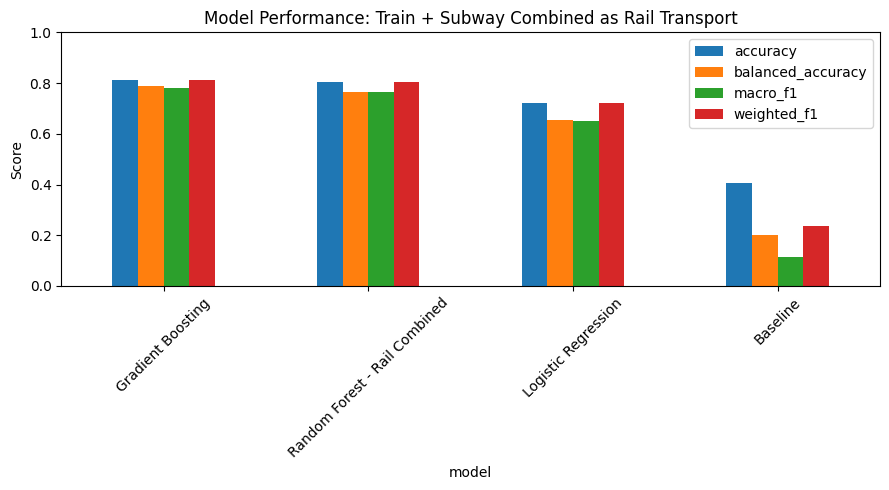

In [ ]:
results_rail_df.set_index("model")[
    ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
].plot(
    kind="bar",
    figsize=(9, 5),
    title="Model Performance: Train + Subway Combined as Rail Transport"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Training models on a dataset with train and subway merged into a single rail transport class did not improve model performance. This suggests that although both modes are track-based, their GPS movement patterns differ enough that combining them may reduce class separability.

confusion matrix for best performing: Gredient boosting

### 5. Apply the trained random forest only to unlabelled GPS data

This version avoids creating one giant `full_points_df`.  
Instead, it processes **one user at a time**:

1. load one user's GPS points,
2. preserve any existing user-given labels,
3. predict only segments where `user_given_mode` is missing,
4. save one parquet file per user,
5. discard the user from memory and continue.

This is much safer for RAM than concatenating the full Geolife dataset.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# New output folder so the speed-based segmentation does not overwrite the previous results
OUTPUT_DIR = Path("/content/drive/MyDrive/GIS2/predicted_users_speed_segments")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving per-user parquet files to:", OUTPUT_DIR)

Saving per-user parquet files to: /content/drive/MyDrive/GIS2/predicted_users_speed_segments


#### Feature engineering for any segment

This is the same feature logic used before, but it can be applied to any segment: labelled or unlabelled.


In [ ]:
def engineer_features_for_any_segment(segment):
    """
    Create one feature row from one GPS segment.
    Works for labelled and unlabelled data.
    """

    segment = segment.sort_values("datetime").copy()

    user_id = segment["user_id"].iloc[0]
    segment_id = segment["segment_id"].iloc[0]
    file_name = segment["file_name"].iloc[0]

    n_points = len(segment)

    start_time = segment["datetime"].min()
    end_time = segment["datetime"].max()
    duration_s = (end_time - start_time).total_seconds()

    if n_points < 2 or duration_s <= 0:
        return None

    segment["prev_lat"] = segment["lat"].shift(1)
    segment["prev_lon"] = segment["lon"].shift(1)
    segment["prev_time"] = segment["datetime"].shift(1)

    segment["step_distance_m"] = haversine_distance(
        segment["prev_lat"],
        segment["prev_lon"],
        segment["lat"],
        segment["lon"]
    )

    segment["step_time_s"] = (
        segment["datetime"] - segment["prev_time"]
    ).dt.total_seconds()

    valid_steps = segment.dropna(subset=["step_distance_m", "step_time_s"]).copy()
    valid_steps = valid_steps[valid_steps["step_time_s"] > 0]

    if len(valid_steps) == 0:
        return None

    valid_steps["speed_mps"] = (
        valid_steps["step_distance_m"] / valid_steps["step_time_s"]
    )

    # Remove unrealistic jumps
    valid_steps = valid_steps[valid_steps["speed_mps"] <= 80]

    if len(valid_steps) == 0:
        return None

    total_distance_m = valid_steps["step_distance_m"].sum()

    avg_speed_mps = total_distance_m / duration_s
    mean_step_speed_mps = valid_steps["speed_mps"].mean()
    median_speed_mps = valid_steps["speed_mps"].median()
    max_speed_mps = valid_steps["speed_mps"].max()
    std_speed_mps = valid_steps["speed_mps"].std()

    valid_steps["prev_speed_mps"] = valid_steps["speed_mps"].shift(1)
    valid_steps["acceleration_mps2"] = (
        valid_steps["speed_mps"] - valid_steps["prev_speed_mps"]
    ) / valid_steps["step_time_s"]

    acceleration = valid_steps["acceleration_mps2"].dropna()

    mean_acceleration_mps2 = acceleration.mean() if len(acceleration) > 0 else np.nan
    max_acceleration_mps2 = acceleration.max() if len(acceleration) > 0 else np.nan
    std_acceleration_mps2 = acceleration.std() if len(acceleration) > 0 else np.nan

    stop_rate = (valid_steps["speed_mps"] < 0.5).mean()

    direct_distance_m = haversine_distance(
        segment["lat"].iloc[0],
        segment["lon"].iloc[0],
        segment["lat"].iloc[-1],
        segment["lon"].iloc[-1]
    )

    straightness_ratio = (
        direct_distance_m / total_distance_m
        if total_distance_m > 0
        else np.nan
    )

    altitude_valid = segment["altitude_m"].dropna()

    if len(altitude_valid) >= 2:
        altitude_change_m = altitude_valid.iloc[-1] - altitude_valid.iloc[0]
        altitude_range_m = altitude_valid.max() - altitude_valid.min()
        altitude_mean_m = altitude_valid.mean()
        altitude_std_m = altitude_valid.std()
    else:
        altitude_change_m = 0
        altitude_range_m = 0
        altitude_mean_m = 0
        altitude_std_m = 0

    return {
        "segment_id": segment_id,
        "user_id": user_id,
        "file_name": file_name,
        "n_points": n_points,
        "duration_s": duration_s,
        "distance_m": total_distance_m,
        "avg_speed_mps": avg_speed_mps,
        "mean_step_speed_mps": mean_step_speed_mps,
        "median_speed_mps": median_speed_mps,
        "max_speed_mps": max_speed_mps,
        "std_speed_mps": std_speed_mps,
        "mean_acceleration_mps2": mean_acceleration_mps2,
        "max_acceleration_mps2": max_acceleration_mps2,
        "std_acceleration_mps2": std_acceleration_mps2,
        "stop_rate": stop_rate,
        "straightness_ratio": straightness_ratio,
        "altitude_change_m": altitude_change_m,
        "altitude_range_m": altitude_range_m,
        "altitude_mean_m": altitude_mean_m,
        "altitude_std_m": altitude_std_m,
        "start_time": start_time,
        "end_time": end_time
    }


#### Add user-given labels to GPS points

Important: these labels are **not overwritten** by the model.


In [ ]:
# Modes used consistently in both model training and final prediction output
MODE_REPLACEMENTS = {
    "taxi": "car_or_taxi",
    "car": "car_or_taxi"
}

EXCLUDED_MODES = ["airplane", "boat", "run", "motorcycle"]
VALID_MODEL_MODES = ["bike", "bus", "car_or_taxi", "subway", "train", "walk"]


def normalize_transport_mode(mode):
    """
    Apply the same mode cleaning as in model training.
    - car and taxi are merged into car_or_taxi
    - rare modes are kept identifiable but excluded from modelling/prediction
    """
    if pd.isna(mode):
        return pd.NA
    return MODE_REPLACEMENTS.get(str(mode), str(mode))


def add_user_given_labels_to_points(traj_df, user_labels):
    """
    Add user-given transportation labels to GPS points.

    Important fix:
    Rare modes that were excluded from model training
    (airplane, boat, run, motorcycle) are also excluded here.

    They are NOT predicted over and NOT included as final transportation_mode.
    Instead, they are stored in excluded_user_mode and later marked with
    label_source = 'excluded_rare_mode'.
    """

    traj_df = traj_df.copy()
    traj_df["user_given_mode"] = pd.Series(pd.NA, index=traj_df.index, dtype="object")
    traj_df["excluded_user_mode"] = pd.Series(pd.NA, index=traj_df.index, dtype="object")
    traj_df["label_start_time"] = pd.NaT
    traj_df["label_end_time"] = pd.NaT

    if len(user_labels) == 0:
        return traj_df

    user_labels = user_labels.copy()
    user_labels["transportation_mode"] = user_labels["transportation_mode"].astype("object")

    for _, row in user_labels.iterrows():
        mode = normalize_transport_mode(row["transportation_mode"])

        mask = (
            (traj_df["datetime"] >= row["start_time"]) &
            (traj_df["datetime"] <= row["end_time"])
        )

        if mode in EXCLUDED_MODES:
            traj_df.loc[mask, "excluded_user_mode"] = mode
        else:
            traj_df.loc[mask, "user_given_mode"] = mode

        traj_df.loc[mask, "label_start_time"] = row["start_time"]
        traj_df.loc[mask, "label_end_time"] = row["end_time"]

    return traj_df


#### Split trajectories into speed-aware prediction segments

This version creates smaller prediction segments before applying the Random Forest. A new segment starts when:

- there is a large time gap between consecutive GPS points,
- the point changes from labelled to unlabelled,
- the user-given label changes, or
- there is a significant change in smoothed point-level speed.

The goal is to avoid predicting one transport mode for a very long trajectory that may actually contain multiple movement phases, such as walking to a taxi, riding in the taxi, and walking again.

The speed threshold is adjustable. The default value below is `speed_jump_mps=5`, meaning that a new unlabelled prediction segment starts when the smoothed speed changes by more than 5 metres per second between consecutive points.


In [ ]:
def split_trajectory_by_time_gap_label_and_speed_change(
    traj_df,
    user_id,
    file_name,
    gap_minutes=20,
    speed_jump_mps=7,
    speed_window=7,
    max_reasonable_speed_mps=60,
    min_speed_change_duration_s=30,
    min_points_between_speed_splits=8
):
    """
    Split one trajectory dataframe into smaller prediction segments.

    A new segment starts when:
    - the time gap is larger than gap_minutes,
    - the point changes from labelled to unlabelled,
    - the user-given mode changes,
    - the smoothed point-level speed changes sharply and the change is sustained.

    Improvements compared with the first speed-aware version:
    - uses a slightly stronger smoothing window,
    - ignores extreme GPS jumps above max_reasonable_speed_mps,
    - does not allow speed-change splits too close together,
    - avoids creating many tiny one-point/two-point fragments.
    """

    traj_df = traj_df.sort_values("datetime").copy()

    # Time gap from previous point
    traj_df["time_gap_s"] = traj_df["datetime"].diff().dt.total_seconds()

    # Previous coordinates for step distance and point-level speed
    traj_df["prev_lat"] = traj_df["lat"].shift(1)
    traj_df["prev_lon"] = traj_df["lon"].shift(1)

    traj_df["step_distance_m"] = haversine_distance(
        traj_df["prev_lat"],
        traj_df["prev_lon"],
        traj_df["lat"],
        traj_df["lon"]
    )

    traj_df["step_speed_mps"] = traj_df["step_distance_m"] / traj_df["time_gap_s"]

    # Invalid or unrealistic point speeds are ignored for the speed-change trigger
    invalid_speed = (
        (traj_df["time_gap_s"] <= 0) |
        (traj_df["step_speed_mps"] < 0) |
        (traj_df["step_speed_mps"] > max_reasonable_speed_mps)
    )
    traj_df.loc[invalid_speed, "step_speed_mps"] = np.nan

    # Smooth speed to reduce tiny GPS-noise based segment breaks
    traj_df["smooth_speed_mps"] = (
        traj_df["step_speed_mps"]
        .rolling(window=speed_window, min_periods=1, center=True)
        .median()
    )

    traj_df["speed_change_mps"] = traj_df["smooth_speed_mps"].diff().abs()

    # Label change logic
    label_block = traj_df["user_given_mode"].fillna("__UNLABELLED__")
    label_changed = label_block.ne(label_block.shift())

    is_unlabelled = traj_df["user_given_mode"].isna()
    large_time_gap = traj_df["time_gap_s"] > gap_minutes * 60

    # First pass: candidate speed changes
    speed_candidate = (
        (traj_df["speed_change_mps"] > speed_jump_mps) &
        is_unlabelled &
        ~large_time_gap &
        ~label_changed
    )

    # Second pass: keep only speed splits that are not too close together.
    # This prevents lots of tiny speed-change fragments.
    speed_changed = pd.Series(False, index=traj_df.index)
    last_speed_split_pos = -10**9
    last_speed_split_time = None

    positions = np.arange(len(traj_df))
    times = traj_df["datetime"].reset_index(drop=True)

    for pos, idx in zip(positions, traj_df.index):
        if not speed_candidate.loc[idx]:
            continue

        enough_points = (pos - last_speed_split_pos) >= min_points_between_speed_splits

        if last_speed_split_time is None:
            enough_time = True
        else:
            enough_time = (
                times.iloc[pos] - last_speed_split_time
            ).total_seconds() >= min_speed_change_duration_s

        if enough_points and enough_time:
            speed_changed.loc[idx] = True
            last_speed_split_pos = pos
            last_speed_split_time = times.iloc[pos]

    new_segment = large_time_gap | label_changed | speed_changed
    new_segment.iloc[0] = True

    # Keep a human-readable reason for inspecting the segmentation
    traj_df["segment_start_reason"] = "same_segment"
    traj_df.loc[label_changed, "segment_start_reason"] = "label_change"
    traj_df.loc[large_time_gap, "segment_start_reason"] = "time_gap"
    traj_df.loc[speed_changed, "segment_start_reason"] = "speed_change"
    traj_df.loc[traj_df.index[0], "segment_start_reason"] = "first_point"

    traj_df["segment_number"] = new_segment.cumsum()

    traj_df["segment_id"] = (
        str(user_id) + "_" +
        file_name.replace(".plt", "") + "_" +
        traj_df["segment_number"].astype(str)
    )

    return traj_df.drop(columns=["prev_lat", "prev_lon", "segment_number"])

#### Process one user at a time

This is the RAM-safe prediction function. It loads one user, preserves existing user labels, creates speed-aware segments for the unlabelled parts, predicts one mode per segment, and saves that user's points as one parquet file.


In [ ]:
def process_one_user_and_save(
    user_id,
    output_dir=OUTPUT_DIR,
    gap_minutes=20,
    speed_jump_mps=5,
    speed_window=7,
    prediction_model=rf_model_detailed
):
    """
    Process one Geolife user without loading the whole dataset into memory.

    Output columns include:
    - user_given_mode: original usable label from labels.txt, if available
    - excluded_user_mode: rare label excluded from modelling, if available
    - predicted_mode: Random Forest prediction, only for unlabelled, non-excluded segments
    - prediction_confidence: max predicted probability for RF predictions
    - transportation_mode: final mode used for analysis/map visualization
    - label_source: user_label, random_forest, excluded_rare_mode, or unlabelled_too_short_or_invalid

    This version uses speed-aware segmentation before prediction and applies
    the same rare-mode exclusion logic as model training.
    """

    trajectory_folder = DATA_ROOT / user_id / "Trajectory"

    if not trajectory_folder.exists():
        return None

    user_labels = labels[labels["user_id"] == user_id].copy()
    user_segments = []

    plt_files = sorted(trajectory_folder.glob("*.plt"))

    for file_path in plt_files:
        traj = load_plt_file(file_path, user_id=user_id)
        traj = traj.dropna(subset=["datetime", "lat", "lon"]).copy()

        if len(traj) < 2:
            continue

        # Fix altitude
        traj["altitude_ft"] = traj["altitude_ft"].replace(-777, np.nan)
        traj["altitude_m"] = traj["altitude_ft"] * 0.3048
        traj["altitude_m"] = traj["altitude_m"].fillna(0)

        # Preserve usable labels and mark excluded rare labels separately
        traj = add_user_given_labels_to_points(traj, user_labels)

        # Split trajectory using labels, time gaps, and significant speed changes
        segmented_traj = split_trajectory_by_time_gap_label_and_speed_change(
            traj,
            user_id=user_id,
            file_name=file_path.name,
            gap_minutes=gap_minutes,
            speed_jump_mps=speed_jump_mps,
            speed_window=speed_window
        )

        user_segments.append(segmented_traj)

    if len(user_segments) == 0:
        return None

    user_points = pd.concat(user_segments, ignore_index=True)

    # Only segments with no usable user label AND no excluded rare label are predicted.
    # This prevents rare labelled modes from being incorrectly forced into one of
    # the six model classes.
    unlabelled_points = user_points[
        user_points["user_given_mode"].isna() &
        user_points["excluded_user_mode"].isna()
    ].copy()

    feature_rows = []

    for segment_id, segment in unlabelled_points.groupby("segment_id"):
        features = engineer_features_for_any_segment(segment)

        if features is not None:
            feature_rows.append(features)

    if len(feature_rows) > 0:
        user_features = pd.DataFrame(feature_rows)

        # Same cleaning rules as training
        user_features_clean = user_features[
            (user_features["n_points"] >= 10) &
            (user_features["duration_s"] >= 60) &
            (user_features["distance_m"] >= 50)
        ].copy()

        user_features_clean[altitude_cols] = user_features_clean[altitude_cols].fillna(0)
        user_features_clean = user_features_clean.dropna(subset=feature_cols).copy()

        if len(user_features_clean) > 0:
            user_features_clean["predicted_mode"] = prediction_model.predict(
                user_features_clean[feature_cols]
            )

            prediction_probs = prediction_model.predict_proba(
                user_features_clean[feature_cols]
            )
            user_features_clean["prediction_confidence"] = prediction_probs.max(axis=1)

            predictions = user_features_clean[[
                "segment_id",
                "predicted_mode",
                "prediction_confidence"
            ]]
        else:
            predictions = pd.DataFrame(columns=[
                "segment_id",
                "predicted_mode",
                "prediction_confidence"
            ])
    else:
        predictions = pd.DataFrame(columns=[
            "segment_id",
            "predicted_mode",
            "prediction_confidence"
        ])

    # Attach predictions back to this user's GPS points
    user_points = user_points.merge(
        predictions,
        on="segment_id",
        how="left"
    )

    # Final transportation mode:
    # 1. keep usable user-given labels if available
    # 2. otherwise use RF prediction if available
    # 3. rare excluded user labels stay out of transportation_mode
    # 4. otherwise leave missing
    user_points["transportation_mode"] = user_points["user_given_mode"].astype("object")

    pred_mask = (
        user_points["transportation_mode"].isna() &
        user_points["predicted_mode"].notna() &
        user_points["excluded_user_mode"].isna()
    )

    user_points.loc[pred_mask, "transportation_mode"] = user_points.loc[pred_mask, "predicted_mode"]

    user_points["label_source"] = "unlabelled_too_short_or_invalid"
    user_points.loc[user_points["user_given_mode"].notna(), "label_source"] = "user_label"
    user_points.loc[user_points["excluded_user_mode"].notna(), "label_source"] = "excluded_rare_mode"
    user_points.loc[pred_mask, "label_source"] = "random_forest"

    # Store text label columns cleanly in Parquet
    for col in ["user_given_mode", "excluded_user_mode", "predicted_mode", "transportation_mode", "label_source"]:
        if col in user_points.columns:
            user_points[col] = user_points[col].astype("string")

    output_path = output_dir / f"user_{user_id}_points_labelled_predicted_speed_segments.parquet"
    user_points.to_parquet(output_path, index=False)

    summary = {
        "user_id": user_id,
        "n_points": len(user_points),
        "n_segments": user_points["segment_id"].nunique(),
        "n_speed_change_segments": (user_points["segment_start_reason"] == "speed_change").sum(),
        "n_user_labelled_points": (user_points["label_source"] == "user_label").sum(),
        "n_excluded_rare_mode_points": (user_points["label_source"] == "excluded_rare_mode").sum(),
        "n_rf_predicted_points": (user_points["label_source"] == "random_forest").sum(),
        "n_still_unlabelled_points": (user_points["label_source"] == "unlabelled_too_short_or_invalid").sum(),
        "gap_minutes": gap_minutes,
        "speed_jump_mps": speed_jump_mps,
        "speed_window": speed_window,
        "output_path": str(output_path)
    }

    return summary


#### Run for all users

This loop saves many small parquet files instead of one massive parquet file.


In [ ]:
processing_summaries = []

for user_path in user_folders:
    user_id = user_path.name
    print("Processing user:", user_id)

    summary = process_one_user_and_save(
        user_id=user_id,
        output_dir=OUTPUT_DIR,
        gap_minutes=20,
        speed_jump_mps=7,
        speed_window=7,
        prediction_model=rf_model_detailed
    )

    if summary is not None:
        processing_summaries.append(summary)

processing_summary_df = pd.DataFrame(processing_summaries)
processing_summary_df.head()

Processing user: 000
Processing user: 001
Processing user: 002
Processing user: 003
Processing user: 004
Processing user: 005
Processing user: 006
Processing user: 007
Processing user: 008
Processing user: 009
Processing user: 010
Processing user: 011
Processing user: 012
Processing user: 013
Processing user: 014
Processing user: 015
Processing user: 016
Processing user: 017
Processing user: 018
Processing user: 019
Processing user: 020
Processing user: 021
Processing user: 022
Processing user: 023
Processing user: 024
Processing user: 025
Processing user: 026
Processing user: 027
Processing user: 028
Processing user: 029
Processing user: 030
Processing user: 031
Processing user: 032
Processing user: 033
Processing user: 034
Processing user: 035
Processing user: 036
Processing user: 037
Processing user: 038
Processing user: 039
Processing user: 040
Processing user: 041
Processing user: 042
Processing user: 043
Processing user: 044
Processing user: 045
Processing user: 046
Processing us

,user_id,n_points,n_segments,n_speed_change_segments,n_user_labelled_points,n_excluded_rare_mode_points,n_rf_predicted_points,n_still_unlabelled_points,gap_minutes,speed_jump_mps,speed_window,output_path
0,000,173870,629,101,0,0,173722,148,20,7,7,/content/drive/MyDrive/GIS2/predicted_users_sp...
1,001,108607,218,68,0,0,108444,163,20,7,7,/content/drive/MyDrive/GIS2/predicted_users_sp...
2,002,248217,527,145,0,0,247885,332,20,7,7,/content/drive/MyDrive/GIS2/predicted_users_sp...
3,003,485226,1388,296,0,0,484901,325,20,7,7,/content/drive/MyDrive/GIS2/predicted_users_sp...
4,004,439397,1699,278,0,0,439120,277,20,7,7,/content/drive/MyDrive/GIS2/predicted_users_sp...


In [ ]:
processing_summary_df.to_csv(
    OUTPUT_DIR / "processing_summary.csv",
    index=False
)

processing_summary_df[[
    "n_points",
    "n_user_labelled_points",
    "n_excluded_rare_mode_points",
    "n_rf_predicted_points",
    "n_still_unlabelled_points"
]].sum()


,0
n_points,24876978
n_user_labelled_points,5425541
n_excluded_rare_mode_points,15075
n_rf_predicted_points,19372673
n_still_unlabelled_points,63689


#### Optional: read one saved user file back in


In [ ]:
example_output = processing_summary_df["output_path"].iloc[0]
example_user_points = pd.read_parquet(example_output)

example_user_points[[
    "user_id",
    "datetime",
    "lat",
    "lon",
    "segment_id",
    "step_speed_mps",
    "smooth_speed_mps",
    "speed_change_mps",
    "segment_start_reason",
    "user_given_mode",
    "excluded_user_mode",
    "predicted_mode",
    "transportation_mode",
    "label_source",
    "prediction_confidence"
]].head()


,user_id,datetime,lat,lon,segment_id,step_speed_mps,smooth_speed_mps,speed_change_mps,segment_start_reason,user_given_mode,excluded_user_mode,predicted_mode,transportation_mode,label_source,prediction_confidence
0,000,2008-10-23 02:53:04,39.984702,116.318417,000_20081023025304_1,NaN,0.566260,NaN,first_point,<NA>,<NA>,bike,bike,random_forest,0.957183
1,000,2008-10-23 02:53:10,39.984683,116.318450,000_20081023025304_1,0.586148,0.576204,0.009944,same_segment,<NA>,<NA>,bike,bike,random_forest,0.957183
2,000,2008-10-23 02:53:15,39.984686,116.318417,000_20081023025304_1,0.566260,0.586148,0.009944,same_segment,<NA>,<NA>,bike,bike,random_forest,0.957183
3,000,2008-10-23 02:53:20,39.984688,116.318385,000_20081023025304_1,0.547087,1.395375,0.809227,same_segment,<NA>,<NA>,bike,bike,random_forest,0.957183
4,000,2008-10-23 02:53:25,39.984655,116.318263,000_20081023025304_1,2.204602,2.204602,0.809227,same_segment,<NA>,<NA>,bike,bike,random_forest,0.957183


#### Inspect speed-aware segments for one example user

This summary helps verify whether the new segmentation creates shorter movement phases. Later, these segments can be ordered by timestamp and combined again into longer trajectories for animation.


In [ ]:
example_segment_summary = (
    example_user_points
    .groupby("segment_id")
    .agg(
        user_id=("user_id", "first"),
        mode=("transportation_mode", "first"),
        label_source=("label_source", "first"),
        start_time=("datetime", "min"),
        end_time=("datetime", "max"),
        n_points=("datetime", "size"),
        start_reason=("segment_start_reason", "first"),
        mean_speed_mps=("step_speed_mps", "mean"),
        max_speed_mps=("step_speed_mps", "max"),
        mean_confidence=("prediction_confidence", "mean")
    )
    .reset_index()
    .sort_values("start_time")
)

example_segment_summary.head(30)

,segment_id,user_id,mode,label_source,start_time,end_time,n_points,start_reason,mean_speed_mps,max_speed_mps,mean_confidence
0,000_20081023025304_1,000,bike,random_forest,2008-10-23 02:53:04,2008-10-23 03:05:15,148,first_point,2.814997,11.609824,0.957183
1,000_20081023025304_2,000,bike,random_forest,2008-10-23 04:08:07,2008-10-23 04:34:52,322,time_gap,2.767582,32.879114,0.437118
2,000_20081023025304_3,000,walk,random_forest,2008-10-23 09:42:25,2008-10-23 10:46:11,425,time_gap,1.526674,17.030580,0.891895
3,000_20081023025304_4,000,walk,random_forest,2008-10-23 11:08:22,2008-10-23 11:11:12,13,time_gap,1.884339,6.701332,0.810269
4,000_20081024020959_1,000,walk,random_forest,2008-10-24 02:09:59,2008-10-24 02:47:06,244,first_point,0.965595,28.924301,0.927338
5,000_20081026134407_1,000,walk,random_forest,2008-10-26 13:44:07,2008-10-26 14:48:57,656,first_point,1.368545,31.078144,0.739405
6,000_20081026134407_2,000,subway,random_forest,2008-10-26 14:49:37,2008-10-26 15:03:42,84,speed_change,14.998258,36.647310,0.605702
7,000_20081026134407_3,000,<NA>,unlabelled_too_short_or_invalid,2008-10-26 15:03:47,2008-10-26 15:04:07,5,speed_change,5.405434,22.004006,NaN
8,000_20081027115449_1,000,walk,random_forest,2008-10-27 11:54:49,2008-10-27 12:05:54,50,first_point,1.972751,5.381922,0.444083
9,000_20081028003826_1,000,walk,random_forest,2008-10-28 00:38:26,2008-10-28 02:57:26,1468,first_point,1.019929,19.798331,0.850534


#### Optional: combine only if needed later

For mapping, it is usually better to load only the users or time window you need. But if you really need one combined file later, combine the per-user parquet files after checking available RAM.


In [ ]:
# Optional, only run if you really need a combined dataframe
# and your runtime has enough memory.

# user_files = sorted(OUTPUT_DIR.glob("user_*_points_labelled_predicted.parquet"))
# combined_points_df = pd.concat(
#     [pd.read_parquet(path) for path in user_files],
#     ignore_index=True
# )
# combined_points_df.to_parquet(
#     OUTPUT_DIR / "all_users_points_labelled_predicted.parquet",
#     index=False
# )


In [ ]:
example_segment_summary["mode"].value_counts(dropna=False)

,count
mode,
bike,237
walk,219
car_or_taxi,76
bus,56
<NA>,27
subway,14


In [ ]:
import matplotlib.pyplot as plt

# Keep only segments that were actually predicted by the model
predicted_only = example_segment_summary[
    example_segment_summary["label_source"] == "random_forest"
].copy()

# Create confidence summary by predicted mode
confidence_by_mode = (
    predicted_only
    .groupby("mode")
    .agg(
        n_segments=("segment_id", "count"),
        mean_confidence=("mean_confidence", "mean"),
        median_confidence=("mean_confidence", "median"),
        min_confidence=("mean_confidence", "min"),
        max_confidence=("mean_confidence", "max")
    )
    .sort_values("mean_confidence", ascending=False)
)

confidence_by_mode

,n_segments,mean_confidence,median_confidence,min_confidence,max_confidence
mode,,,,,
bike,237,0.807956,0.852223,0.317928,0.995107
walk,219,0.769201,0.819611,0.294305,0.997536
car_or_taxi,76,0.607382,0.570466,0.267688,0.982500
bus,56,0.544562,0.487557,0.264855,0.963966
subway,14,0.449163,0.442335,0.339886,0.605702


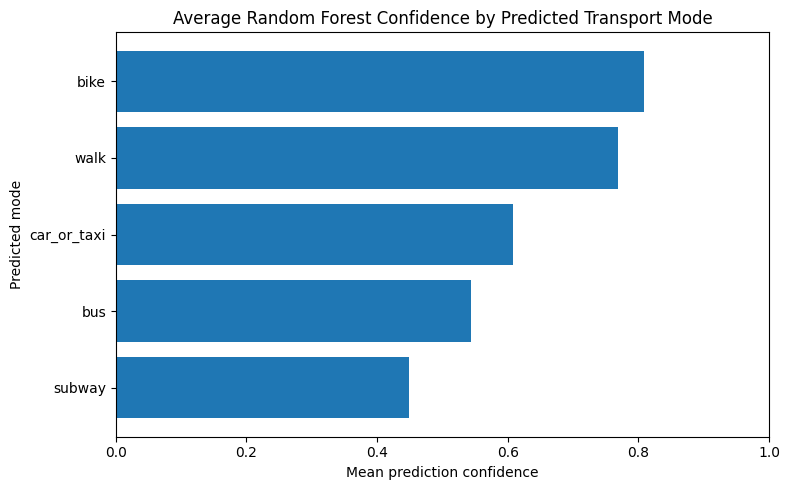

In [ ]:
import matplotlib.pyplot as plt

plot_df = confidence_by_mode.sort_values("mean_confidence")

plt.figure(figsize=(8, 5))
plt.barh(plot_df.index, plot_df["mean_confidence"])
plt.xlabel("Mean prediction confidence")
plt.ylabel("Predicted mode")
plt.title("Average Random Forest Confidence by Predicted Transport Mode")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()